In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import time
import warnings
warnings.filterwarnings("ignore")

In [2]:
# importing data
comex = pd.read_csv('comex_60.csv')
equity = pd.read_csv('equity_60.csv')

In [3]:
comex["Time"] = pd.to_datetime(comex["Time"])
equity["Time"] = pd.to_datetime(equity["Time"])

comex = comex.sort_values(["Time", "symbol"]).reset_index(drop=True)
equity = equity.sort_values(["Time", "symbol"]).reset_index(drop=True)

In [4]:
comex["root"] = np.where(
    comex["symbol"].str.startswith("MGC"),
    "MGC",
    "GC"
)

comex.head()

,Time,symbol,vwap_traded_volume,uptick_volume,downtick_volume,root
0,2025-08-17 18:01:00,GC\U25,2,1,1,GC
1,2025-08-17 18:01:00,GC\V25,21,5,15,GC
2,2025-08-17 18:01:00,GC\Z25,196,60,67,GC
3,2025-08-17 18:01:00,MGC\V25,71,47,15,MGC
4,2025-08-17 18:01:00,MGC\Z25,353,122,84,MGC


In [5]:
gld = equity[equity["symbol"] == "GLD"].copy()
gld.head()

,Time,symbol,vwap,vwap_traded_volume
0,2025-08-18 04:01:00,GLD,308.256568,338
4,2025-08-18 04:02:00,GLD,308.458911,101
8,2025-08-18 04:03:00,GLD,308.296058,137
11,2025-08-18 04:04:00,GLD,308.215586,111
15,2025-08-18 04:05:00,GLD,308.283740,123


### Data preprocessing

In [6]:
# aggregate GC and MGC volume across all expiries
# aggregate trading activity across all expiries for GC and MGC
futures = (
    comex.groupby(["Time", "root"], as_index=False)
    .agg(
        volume=("vwap_traded_volume", "sum"),
        uptick_volume=("uptick_volume", "sum"),
        downtick_volume=("downtick_volume", "sum")
    )
)

futures.head()

,Time,root,volume,uptick_volume,downtick_volume
0,2025-08-17 18:01:00,GC,219,66,83
1,2025-08-17 18:01:00,MGC,424,169,99
2,2025-08-17 18:02:00,GC,114,27,49
3,2025-08-17 18:02:00,MGC,227,55,59
4,2025-08-17 18:03:00,GC,170,49,56


In [7]:
# pivot GC and MGC into separate columns
futures = futures.pivot(
    index="Time",
    columns="root",
    values=[
        "volume",
        "uptick_volume",
        "downtick_volume"
    ]
)

futures.columns = [
    f"{root}_{feature}"
    for feature, root in futures.columns
]

futures = futures.reset_index()

futures.head()

,Time,GC_volume,MGC_volume,GC_uptick_volume,MGC_uptick_volume,GC_downtick_volume,MGC_downtick_volume
0,2025-08-17 18:01:00,219.0,424.0,66.0,169.0,83.0,99.0
1,2025-08-17 18:02:00,114.0,227.0,27.0,55.0,49.0,59.0
2,2025-08-17 18:03:00,170.0,545.0,49.0,110.0,56.0,123.0
3,2025-08-17 18:04:00,257.0,385.0,75.0,105.0,78.0,83.0
4,2025-08-17 18:05:00,62.0,207.0,21.0,50.0,19.0,53.0


In [8]:
# storing only the required GLD variables
gld = gld[
    [
        "Time",
        "vwap",
        "vwap_traded_volume"
    ]
].copy()

gld = gld.rename(
    columns={
        "vwap": "GLD_vwap",
        "vwap_traded_volume": "GLD_volume"
    }
)

gld.head()

,Time,GLD_vwap,GLD_volume
0,2025-08-18 04:01:00,308.256568,338
4,2025-08-18 04:02:00,308.458911,101
8,2025-08-18 04:03:00,308.296058,137
11,2025-08-18 04:04:00,308.215586,111
15,2025-08-18 04:05:00,308.283740,123


In [9]:
# merge futures and GLD
data = pd.merge(
    gld,
    futures,
    on="Time",
    how="left"
)

data = data.sort_values("Time").reset_index(drop=True)

data.head()

,Time,GLD_vwap,GLD_volume,GC_volume,MGC_volume,GC_uptick_volume,MGC_uptick_volume,GC_downtick_volume,MGC_downtick_volume
0,2025-08-18 04:01:00,308.256568,338,122.0,142.0,39.0,23.0,21.0,24.0
1,2025-08-18 04:02:00,308.458911,101,120.0,75.0,27.0,15.0,25.0,16.0
2,2025-08-18 04:03:00,308.296058,137,371.0,70.0,30.0,7.0,165.0,19.0
3,2025-08-18 04:04:00,308.215586,111,191.0,143.0,50.0,21.0,36.0,16.0
4,2025-08-18 04:05:00,308.283740,123,146.0,239.0,30.0,13.0,45.0,51.0


In [10]:
data.isna().sum()

Time                       0
GLD_vwap                 198
GLD_volume                 0
GC_volume              23115
MGC_volume             38902
GC_uptick_volume       23115
MGC_uptick_volume      38902
GC_downtick_volume     23115
MGC_downtick_volume    38902
dtype: int64

In [11]:
data.shape

(233392, 9)

### Setting up the baseline volume-surge model

In [12]:
# create the prediction targets (it maps the shifted future price of GLD to the current time, instead of shifting by dataframe rows)
horizons = [1, 5, 10, 30]

price_lookup = data.set_index("Time")["GLD_vwap"]

for h in horizons:
    future_times = data["Time"] + pd.Timedelta(minutes=h)

    future_price = future_times.map(price_lookup)

    data[f"GLD_fwd_{h}m"] = (
        future_price / data["GLD_vwap"] - 1
    )

    data[f"GLD_fwd_{h}m_bps"] = (
        data[f"GLD_fwd_{h}m"] * 10000
    )

In [13]:
# adding time-of-day (TOD)
data["date"] = data["Time"].dt.date
data["time"] = data["Time"].dt.time
data["hour"] = data["Time"].dt.hour
data["minute"] = data["Time"].dt.minute

In [14]:
# baseline model
# calculate the 30-minute rolling mean of GC volume
data["GC_rollmean_30_prior"] = (
    data["GC_volume"]
    .shift(1)
    .rolling(window=30, min_periods=5)
    .mean()
)

# calculate the raw GC signal as the ratio of GC volume to its 30-minute rolling mean
data["GC_raw_30_prior"] = (
    data["GC_volume"] / data["GC_rollmean_30_prior"]
)

# calculate the long-run scale of the GC signal using an expanding mean of the absolute value of the raw signal
data["GC_long_run_scale"] = (
    data["GC_raw_30_prior"]
    .abs()
    .expanding(min_periods=30)
    .mean()
    .shift(1)
)

# calculate the final GC signal as the ratio of the raw signal to its long-run scale
data["GC_signal_30"] = (
    data["GC_raw_30_prior"] / data["GC_long_run_scale"]
)

In [15]:
# checking the baseline features
data[
    [
        "Time",
        "GC_volume",
        "GC_rollmean_30_prior",
        "GC_raw_30_prior",
        "GC_long_run_scale",
        "GC_signal_30"
    ]
].head(40)

,Time,GC_volume,GC_rollmean_30_prior,GC_raw_30_prior,GC_long_run_scale,GC_signal_30
0,2025-08-18 04:01:00,122.0,NaN,NaN,NaN,NaN
1,2025-08-18 04:02:00,120.0,NaN,NaN,NaN,NaN
2,2025-08-18 04:03:00,371.0,NaN,NaN,NaN,NaN
3,2025-08-18 04:04:00,191.0,NaN,NaN,NaN,NaN
4,2025-08-18 04:05:00,146.0,NaN,NaN,NaN,NaN
5,2025-08-18 04:06:00,179.0,190.000000,0.942105,NaN,NaN
6,2025-08-18 04:07:00,72.0,188.166667,0.382640,NaN,NaN
7,2025-08-18 04:08:00,100.0,171.571429,0.582848,NaN,NaN
8,2025-08-18 04:09:00,127.0,162.625000,0.780938,NaN,NaN
9,2025-08-18 04:10:00,145.0,158.666667,0.913866,NaN,NaN


### Baseline signal evaluation

In [16]:
# extract the baseline close window
baseline = data[
    (data["Time"].dt.time >= time(15, 0)) &
    (data["Time"].dt.time < time(16, 0))
].copy()

baseline = baseline.dropna(
    subset=[
        "GC_signal_30",
        "GLD_fwd_1m",
        "GLD_fwd_5m",
        "GLD_fwd_10m",
        "GLD_fwd_30m"
    ]
)

print("Baseline observations:", len(baseline))
print("Trading days:", baseline["date"].nunique())  

Baseline observations: 14607
Trading days: 246


In [17]:
# information coefficient
ic_results = []

for h in [1, 5, 10, 30]:
    temp = baseline[["GC_signal_30", f"GLD_fwd_{h}m"]].dropna()

    ic = temp["GC_signal_30"].corr(
        temp[f"GLD_fwd_{h}m"]
    )

    ic_results.append({
        "horizon": h,
        "IC": ic,
        "n_obs": len(temp)
    })

ic_results = pd.DataFrame(ic_results)

ic_results

,horizon,IC,n_obs
0,1,-0.004213,14607
1,5,0.000703,14607
2,10,0.004589,14607
3,30,0.016607,14607


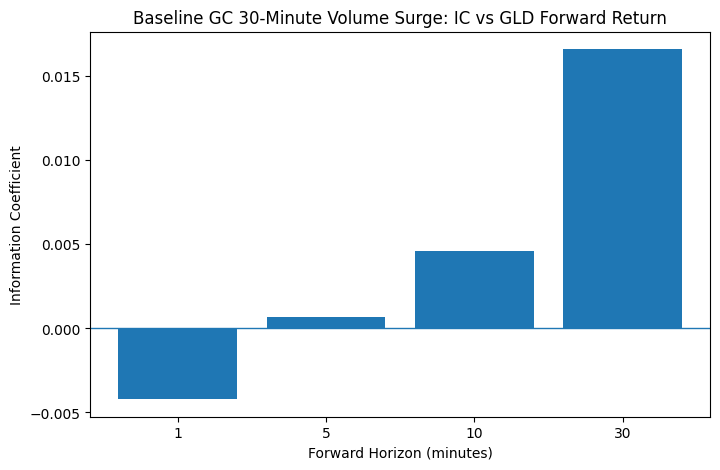

In [18]:
# baseline plot
plt.figure(figsize=(8, 5))

plt.bar(
    ic_results["horizon"].astype(str),
    ic_results["IC"]
)

plt.axhline(0, linewidth=1)

plt.xlabel("Forward Horizon (minutes)")
plt.ylabel("Information Coefficient")
plt.title("Baseline GC 30-Minute Volume Surge: IC vs GLD Forward Return")

plt.show()

#### Candidate evaluation methodology (shared)

**Signal screen:** Pearson / Spearman IC on the Close window (15:00-16:00).

**Strategy diagnostic (provisional):**
- `position = 1` when signal exceeds the expanding 80th percentile of all prior signals (lagged 1 bar; no look-ahead)
- `position = 0` otherwise
- non-overlapping entries: no new trade until the GLD hold horizon finishes
- `strategy_return = position * GLD_forward_return`

**Full diagnostic package (per selected candidate only):** metrics table, scatter + 5-quintile plot, cumulative PnL.
Descriptive quintiles in plots use full-sample `qcut` for visualization only, not for trading thresholds.


In [19]:
def historical_top_quintile_position(signal, min_history=50):
    """Long-only position when signal exceeds prior expanding 80th percentile."""
    thresh = (
        signal
        .expanding(min_periods=min_history)
        .quantile(0.80)
        .shift(1)
    )
    pos = (signal > thresh).astype(float)
    return pos.where(thresh.notna())


def build_nonoverlapping_trades(sample, horizon_minutes):
    """Keep one non-overlapping entry per hold period."""
    rows = []
    next_free = None

    for row in sample.sort_values("Time").itertuples(index=False):
        if next_free is not None and row.Time < next_free:
            continue
        if row.position != 1:
            continue

        rows.append({
            "Time": row.Time,
            "date": row.date,
            "strategy_return": row.fwd_return,
            "strategy_return_bps": row.fwd_return_bps,
        })
        next_free = row.Time + pd.Timedelta(minutes=horizon_minutes)

    return pd.DataFrame(rows)


def close_window_sample(signal_col, horizon):
    """Build Close-session sample for one signal and GLD horizon."""
    fwd = f"GLD_fwd_{horizon}m"
    fwd_bps = f"GLD_fwd_{horizon}m_bps"

    sample = data[
        (data["Time"].dt.time >= time(15, 0)) &
        (data["Time"].dt.time < time(16, 0))
    ][["Time", "date", signal_col, fwd, fwd_bps]].dropna().copy()

    return sample.rename(columns={
        signal_col: "signal",
        fwd: "fwd_return",
        fwd_bps: "fwd_return_bps",
    })


def candidate_metrics(candidate_id, signal_col, horizon):
    """Compute IC and strategy metrics for one candidate (no plots)."""
    sample = close_window_sample(signal_col, horizon)

    pearson_ic = sample["signal"].corr(sample["fwd_return"])
    spearman_ic = sample["signal"].corr(sample["fwd_return"], method="spearman")

    sample["position"] = historical_top_quintile_position(sample["signal"])
    trades = build_nonoverlapping_trades(sample.dropna(subset=["position"]), horizon)

    if len(trades) == 0:
        return {
            "candidate": candidate_id,
            "horizon": horizon,
            "pearson_ic": pearson_ic,
            "spearman_ic": spearman_ic,
            "avg_bps_per_trade": np.nan,
            "hit_rate": np.nan,
            "sharpe": np.nan,
            "sortino": np.nan,
            "n_trades": 0,
            "n_days": 0,
            "max_drawdown_bps": np.nan,
        }, sample, trades

    daily = trades.groupby("date")["strategy_return"].sum()
    daily_mean = daily.mean()
    daily_std = daily.std(ddof=1)
    downside = daily[daily < 0]
    downside_std = downside.std(ddof=1) if len(downside) > 1 else np.nan

    sharpe = (
        (daily_mean / daily_std) * np.sqrt(252)
        if daily_std and daily_std > 0 else np.nan
    )
    sortino = (
        (daily_mean / downside_std) * np.sqrt(252)
        if downside_std and downside_std > 0 else np.nan
    )

    bps = trades["strategy_return_bps"]
    max_dd = (bps.cumsum() - bps.cumsum().cummax()).min()

    metrics = {
        "candidate": candidate_id,
        "horizon": horizon,
        "pearson_ic": pearson_ic,
        "spearman_ic": spearman_ic,
        "avg_bps_per_trade": bps.mean(),
        "hit_rate": (bps > 0).mean(),
        "sharpe": sharpe,
        "sortino": sortino,
        "n_trades": len(trades),
        "n_days": trades["date"].nunique(),
        "max_drawdown_bps": max_dd,
    }
    return metrics, sample, trades


def plot_candidate_diagnostics(candidate_id, sample, trades):
    """Scatter + 5-quintile diagnostic and cumulative PnL for one candidate."""
    spearman_ic = sample["signal"].corr(sample["fwd_return"], method="spearman")
    pearson_ic = sample["signal"].corr(sample["fwd_return"])

    q_means = (
        sample.assign(
            plot_quintile=pd.qcut(
                sample["signal"],
                q=5,
                labels=["Q1", "Q2", "Q3", "Q4", "Q5"],
                duplicates="drop",
            )
        )
        .groupby("plot_quintile", observed=True)
        .agg(mean_signal=("signal", "mean"), mean_fwd_bps=("fwd_return_bps", "mean"))
        .reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(sample["signal"], sample["fwd_return_bps"], s=8, alpha=0.15)
    axes[0].axhline(0, linewidth=1)
    axes[0].set_xlabel("signal")
    axes[0].set_ylabel("GLD forward return (bps)")
    axes[0].set_title(f"{candidate_id}: signal vs forward return")

    axes[1].scatter(q_means["mean_signal"], q_means["mean_fwd_bps"], s=60)
    axes[1].axhline(0, linewidth=1)
    axes[1].set_xlabel("mean signal in quintile")
    axes[1].set_ylabel("mean forward return (bps)")
    axes[1].set_title(f"{candidate_id}: 5 quintile means")
    for _, row in q_means.iterrows():
        axes[1].annotate(
            row["plot_quintile"],
            (row["mean_signal"], row["mean_fwd_bps"]),
            textcoords="offset points",
            xytext=(6, 4),
            fontsize=9,
        )

    fig.suptitle(
        f"{candidate_id} | Spearman IC={spearman_ic:.4f} | Pearson IC={pearson_ic:.4f}",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

    if len(trades) == 0:
        print("No trades under the position rule.")
        return

    trades = trades.sort_values("Time").copy()
    trades["cum_bps"] = trades["strategy_return_bps"].cumsum()

    plt.figure(figsize=(10, 4))
    plt.plot(trades["Time"], trades["cum_bps"])
    plt.title(f"{candidate_id}: cumulative strategy PnL (bps)")
    plt.ylabel("cumulative bps")
    plt.xlabel("time")
    plt.tight_layout()
    plt.show()


#### Baseline candidate evaluation

Full diagnostic package for the original baseline once: `GC_signal_30`, Close window, 30-minute GLD horizon.
Later subsections reference this numerically instead of re-plotting the baseline.


In [20]:
baseline_metrics, baseline_sample, baseline_trades = candidate_metrics(
    "baseline_30_h30",
    "GC_signal_30",
    30,
)

pd.DataFrame([baseline_metrics])


,candidate,horizon,pearson_ic,spearman_ic,avg_bps_per_trade,hit_rate,sharpe,sortino,n_trades,n_days,max_drawdown_bps
0,baseline_30_h30,30,0.016617,-0.00085,0.124406,0.504202,0.122933,0.17305,476,245,-536.898551


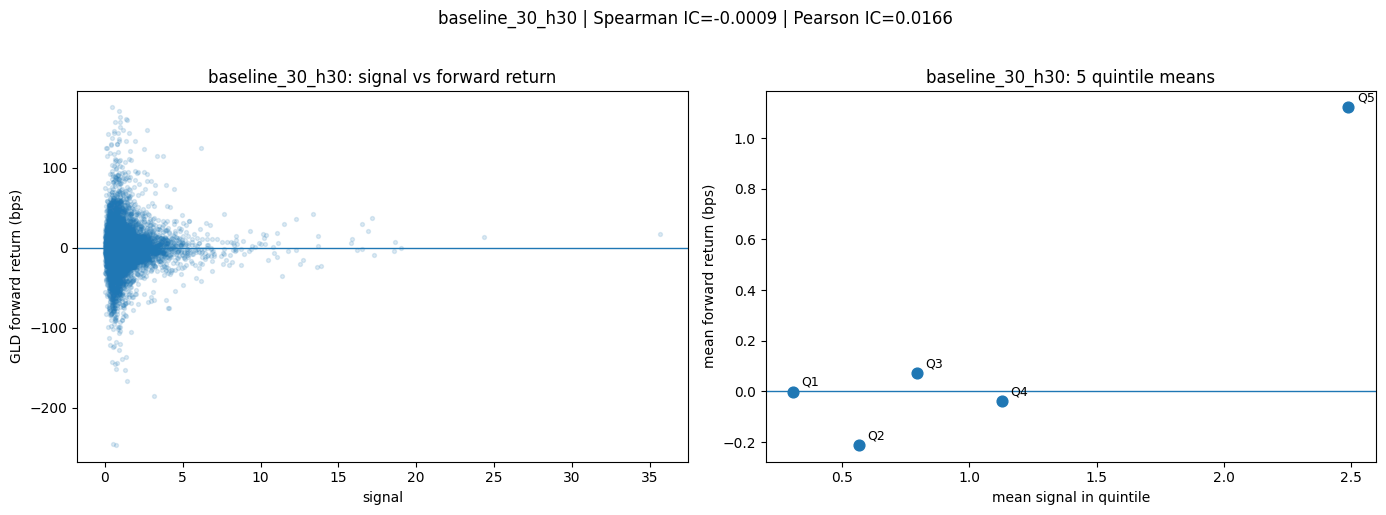

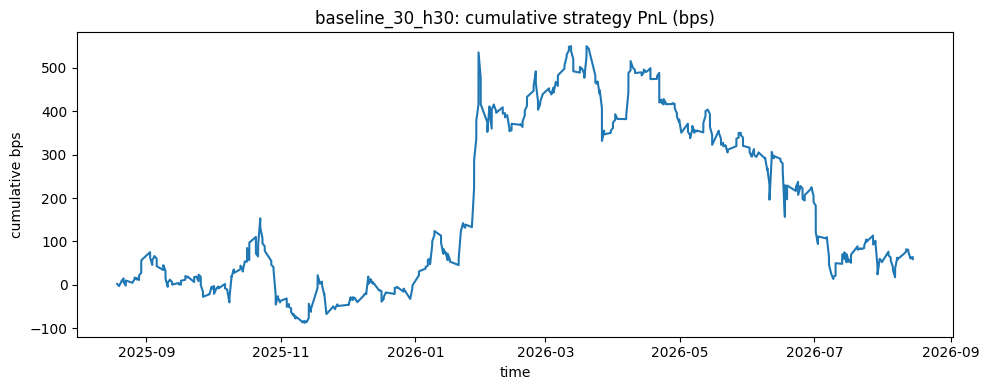

In [21]:
plot_candidate_diagnostics(
    "baseline_30_h30",
    baseline_sample,
    baseline_trades,
)


- IC measures the linear association between the GC volume-surge signal and subsequent GLD returns. 
- Quintile analysis complements IC by checking whether the relationship is nonlinear or concentrated among unusually large volume surges.

In [22]:
# checking stability across days to prevent one day from dominating the results
daily_ic = []

for h in horizons:
    daily = (
        baseline.groupby("date")
        .apply(
            lambda x: x["GC_signal_30"].corr(
                x[f"GLD_fwd_{h}m"]
            ),
            include_groups=False
        )
        .dropna()
    )

    for date, ic in daily.items():
        daily_ic.append({
            "date": date,
            "horizon": h,
            "IC": ic
        })

daily_ic = pd.DataFrame(daily_ic)

daily_ic.head(10)

,date,horizon,IC
0,2025-08-18,1,-0.038250
1,2025-08-19,1,-0.088200
2,2025-08-20,1,-0.061396
3,2025-08-21,1,0.129789
4,2025-08-22,1,0.090670
5,2025-08-25,1,0.108779
6,2025-08-26,1,-0.004337
7,2025-08-27,1,0.104320
8,2025-08-28,1,0.183298
9,2025-08-29,1,0.078271


In [23]:
# summary table for above relationship
daily_ic_summary = (
    daily_ic.groupby("horizon")["IC"]
    .agg(["mean", "median", "std", "count"])
)

daily_ic_summary["positive_days_pct"] = (
    daily_ic.groupby("horizon")["IC"]
    .apply(lambda x: (x > 0).mean() * 100)
)

daily_ic_summary

,mean,median,std,count,positive_days_pct
horizon,,,,,
1,0.005262,0.002866,0.147196,246,50.406504
5,0.005812,0.007302,0.159201,246,50.813008
10,0.012103,0.012728,0.187987,246,51.626016
30,0.014603,0.032372,0.216873,246,55.691057


the aim to check whether the baseline effect repeats through time rather than being concentrated in isolated days

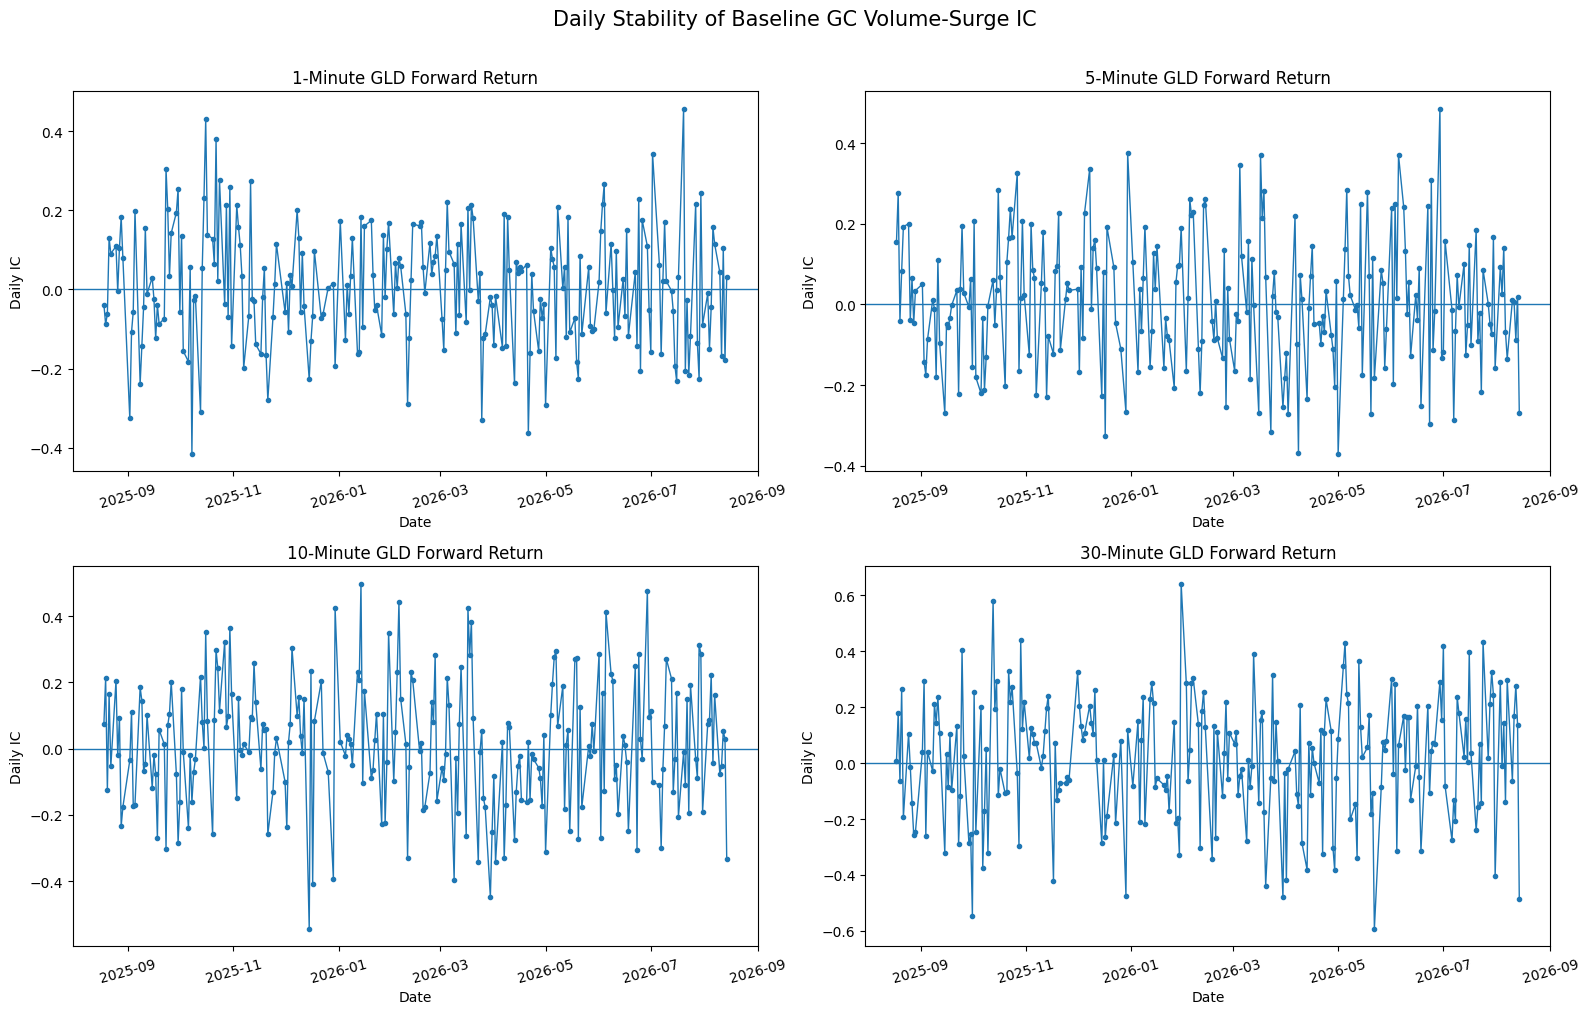

In [24]:
# visualizing the above relationship
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=False)
axes = axes.flatten()

for ax, h in zip(axes, horizons):

    temp = daily_ic[daily_ic["horizon"] == h].copy()
    temp["date"] = pd.to_datetime(temp["date"])

    ax.plot(
        temp["date"],
        temp["IC"],
        marker="o",
        markersize=3,
        lw=1
    )

    ax.axhline(0, linewidth=1)

    ax.set_xlabel("Date")
    ax.set_ylabel("Daily IC")
    ax.set_title(f"{h}-Minute GLD Forward Return")

    ax.tick_params(axis="x", rotation=15)

plt.suptitle(
    "Daily Stability of Baseline GC Volume-Surge IC",
    fontsize=15,
    y=1.01
)

plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

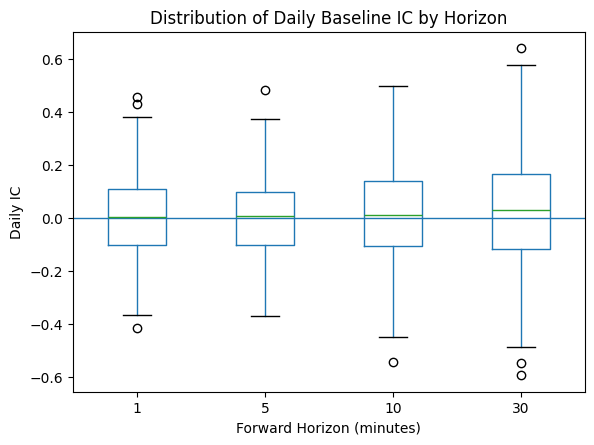

In [25]:
# checking which horizon has the more consistently positive/negative daily relationship
plt.figure(figsize=(8, 5))

daily_ic.boxplot(
    column="IC",
    by="horizon",
    grid=False
)

plt.axhline(0, linewidth=1)

plt.xlabel("Forward Horizon (minutes)")
plt.ylabel("Daily IC")
plt.title("Distribution of Daily Baseline IC by Horizon")
plt.suptitle("")

plt.show()

- if the whole box is mostly above zero, then it's a strongly positive signal
- if it's centered around zero with huge dispersion, then the relationship is unstable (*in our case*)
- if the median is negative but the mean is positive, then we have a too strong positive outliers

In [26]:
# converting the volume signal surge process into a function for future use
def volume_surge_signal(volume, lookback, min_periods=5):
    
    prior_mean = (
        volume
        .shift(1)
        .rolling(
            window=lookback,
            min_periods=min_periods
        )
        .mean()
    )

    raw = volume / prior_mean

    long_run_scale = (
        raw.abs()
        .expanding(min_periods=30)
        .mean()
        .shift(1)
    )

    signal = raw / long_run_scale

    return signal 

### A. Lookback window

#### Method note: lookback windows

Volume lookbacks use pandas row-based rolling (e.g. `rolling(30)` = prior 30 available minute bars), not a strict clock-time window. In the main Close screen (15:00-16:00), missing minutes are rare: about 99.6% of days have all 60 bars, and about 99.96% of consecutive close-session gaps are exactly 1 minute. So the row-based lookback is approximately the intended clock-minute window for these screens.


*The baseline used a 30-minute trailing average. Sweep alternative lookbacks such as: 5, 10, 15, 30, 60, 90, 120 minutes and evaluate:*
- *Whether optimal lookback varies by session (open vs close)*
- *Expanding vs rolling normalization; sensitivity to minimum history before the signal is valid*

In [27]:
# constructing the signals for the lookback windows
lookbacks = [5, 10, 15, 30, 60, 90, 120]

for lb in lookbacks:
    data[f"GC_signal_{lb}"] = volume_surge_signal(
        data["GC_volume"],
        lookback=lb,
        min_periods=5
    )

In [28]:
# compare every lookback against every GLD forward horizon in the original close window, fixing the time-of-day
lookback_results = []

for lb in lookbacks:
    for h in horizons:

        temp = data[
            (data["Time"].dt.time >= time(15, 0)) &
            (data["Time"].dt.time < time(16, 0))
        ][
            [f"GC_signal_{lb}", f"GLD_fwd_{h}m"]
        ].dropna()

        ic = temp[f"GC_signal_{lb}"].corr(
            temp[f"GLD_fwd_{h}m"]
        )

        lookback_results.append({
            "lookback": lb,
            "horizon": h,
            "IC": ic,
            "n_obs": len(temp)
        })

lookback_results = pd.DataFrame(lookback_results)

lookback_results

,lookback,horizon,IC,n_obs
0,5,1,0.002504,14571
1,5,5,-0.002578,14571
2,5,10,-0.003675,14569
3,5,30,0.002113,14527
4,10,1,-0.003068,14632
5,10,5,-0.003676,14632
6,10,10,-0.003398,14630
7,10,30,0.006889,14588
8,15,1,-0.003963,14641
9,15,5,-0.001776,14641


In [29]:
# pivoting the results
lookback_ic_matrix = lookback_results.pivot(
    index="lookback",
    columns="horizon",
    values="IC"
)

lookback_ic_matrix

horizon,1,5,10,30
lookback,,,,
5,0.002504,-0.002578,-0.003675,0.002113
10,-0.003068,-0.003676,-0.003398,0.006889
15,-0.003963,-0.001776,-0.000388,0.010805
30,-0.003982,0.000964,0.004750,0.016617
60,-0.002630,0.001563,0.004824,0.021547
90,0.000017,0.003196,0.008344,0.029585
120,-0.001169,0.001630,0.006207,0.028562


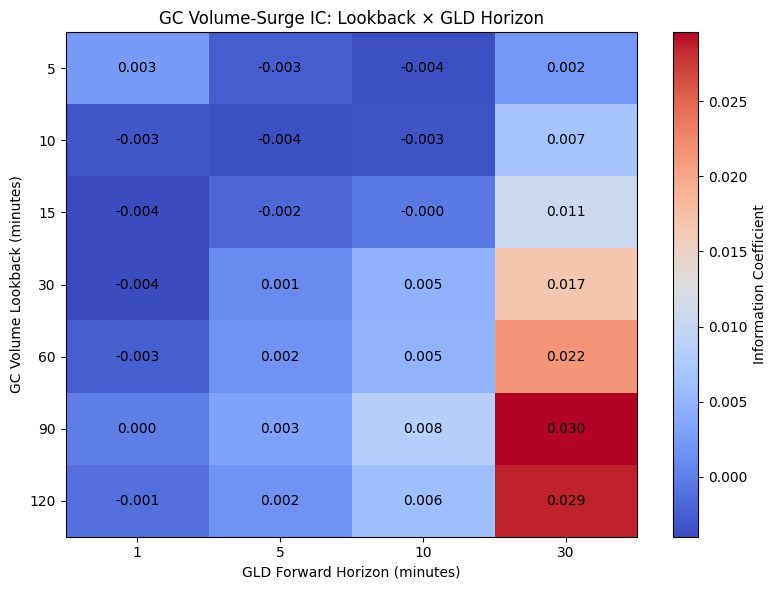

In [30]:
# creating a heatmap to visualize the IC results across lookback windows and horizons to check the storngest relationship
plt.figure(figsize=(8, 6))

plt.imshow(
    lookback_ic_matrix.values,
    aspect="auto",
    cmap="coolwarm",
)

plt.colorbar(label="Information Coefficient")

plt.xticks(
    range(len(lookback_ic_matrix.columns)),
    lookback_ic_matrix.columns
)

plt.yticks(
    range(len(lookback_ic_matrix.index)),
    lookback_ic_matrix.index
)

plt.xlabel("GLD Forward Horizon (minutes)")
plt.ylabel("GC Volume Lookback (minutes)")
plt.title("GC Volume-Surge IC: Lookback × GLD Horizon")

for i in range(len(lookback_ic_matrix.index)):
    for j in range(len(lookback_ic_matrix.columns)):
        plt.text(
            j,
            i,
            f"{lookback_ic_matrix.iloc[i, j]:.3f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

#### A.1 Whether optimal lookback varies by session (open vs close)

check the open (09:30–10:00) vs close (15:00–16:00) case

In [31]:
# comparing lookback performance between the market open and close
sessions = {
    "Open": (time(9, 30), time(10, 0)),
    "Close": (time(15, 0), time(16, 0))
}

session_results = []

for session_name, (start_time, end_time) in sessions.items():

    session_data = data[
        (data["Time"].dt.time >= start_time) &
        (data["Time"].dt.time < end_time)
    ]

    for lb in lookbacks:
        for h in horizons:

            temp = session_data[
                [f"GC_signal_{lb}", f"GLD_fwd_{h}m"]
            ].dropna()

            ic = temp[f"GC_signal_{lb}"].corr(
                temp[f"GLD_fwd_{h}m"]
            )

            session_results.append({
                "session": session_name,
                "lookback": lb,
                "horizon": h,
                "IC": ic,
                "n_obs": len(temp)
            })

session_results = pd.DataFrame(session_results)

session_results.head()

,session,lookback,horizon,IC,n_obs
0,Open,5,1,-0.027263,7383
1,Open,5,5,0.004079,7383
2,Open,5,10,-0.002802,7383
3,Open,5,30,-0.000845,7383
4,Open,10,1,-0.022396,7394


In [32]:
# create separate lookback × horizon IC tables for the open and close
open_ic_matrix = (
    session_results[
        session_results["session"] == "Open"
    ]
    .pivot(
        index="lookback",
        columns="horizon",
        values="IC"
    )
)

close_ic_matrix = (
    session_results[
        session_results["session"] == "Close"
    ]
    .pivot(
        index="lookback",
        columns="horizon",
        values="IC"
    )
)

print('\n Open:')
display(open_ic_matrix)
print('\n Close:')
display(close_ic_matrix)


 Open:


horizon,1,5,10,30
lookback,,,,
5,-0.027263,0.004079,-0.002802,-0.000845
10,-0.022396,0.000531,-0.008457,-0.005371
15,-0.022958,0.000844,-0.010803,-0.008956
30,-0.019448,0.004970,-0.003165,-0.013860
60,-0.021993,0.003642,-0.008034,-0.029698
90,-0.023095,-0.000911,-0.012894,-0.033968
120,-0.021953,0.003821,-0.005092,-0.022455



 Close:


horizon,1,5,10,30
lookback,,,,
5,0.002504,-0.002578,-0.003675,0.002113
10,-0.003068,-0.003676,-0.003398,0.006889
15,-0.003963,-0.001776,-0.000388,0.010805
30,-0.003982,0.000964,0.004750,0.016617
60,-0.002630,0.001563,0.004824,0.021547
90,0.000017,0.003196,0.008344,0.029585
120,-0.001169,0.001630,0.006207,0.028562


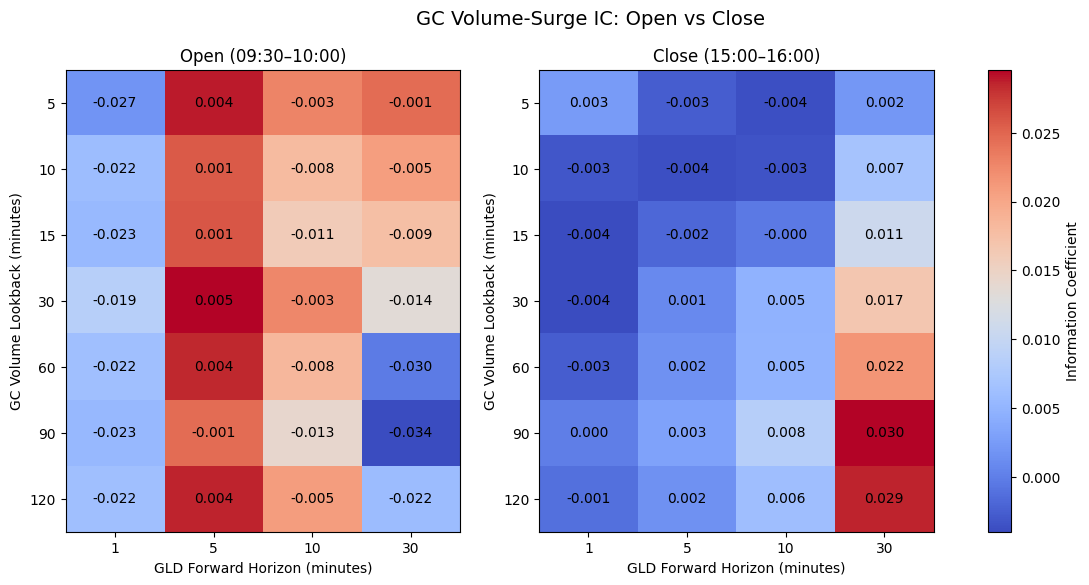

In [33]:
# visualize whether the preferred lookback changes between the open and close
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

matrices = {
    "Open (09:30–10:00)": open_ic_matrix,
    "Close (15:00–16:00)": close_ic_matrix
}

for ax, (title, matrix) in zip(axes, matrices.items()):

    im = ax.imshow(
        matrix.values,
        aspect="auto",
        cmap="coolwarm"
    )

    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns)

    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index)

    ax.set_xlabel("GLD Forward Horizon (minutes)")
    ax.set_ylabel("GC Volume Lookback (minutes)")
    ax.set_title(title)

    for i in range(len(matrix.index)):
        for j in range(len(matrix.columns)):
            ax.text(
                j,
                i,
                f"{matrix.iloc[i, j]:.3f}",
                ha="center",
                va="center"
            )

fig.colorbar(im, ax=axes, label="Information Coefficient")

plt.suptitle(
    "GC Volume-Surge IC: Open vs Close",
    fontsize=14
)

plt.show()

#### A.1 candidate selection

Close-session screen at the 30-minute GLD horizon: lookback 30 IC ~0.017; lookbacks 90 and 120 IC ~0.030 and ~0.029.
Both longer lookbacks beat the baseline and are close to each other, so each gets a full diagnostic package.
The baseline full package lives in the baseline section above and is not re-plotted here.


In [34]:
# compact IC comparison (screen only; baseline not re-plotted)
a1_ic_compare = (
    lookback_results[
        (lookback_results["lookback"].isin([30, 90, 120])) &
        (lookback_results["horizon"] == 30)
    ]
    .rename(columns={"IC": "pearson_ic_close"})
    .sort_values("lookback")
)

a1_ic_compare


,lookback,horizon,pearson_ic_close,n_obs
15,30,30,0.016617,14609
23,90,30,0.029585,14623
27,120,30,0.028562,14624


In [35]:
# full diagnostics: two selected non-baseline candidates
a1_selected = [
    ("A1_lb90_h30", "GC_signal_90"),
    ("A1_lb120_h30", "GC_signal_120"),
]

a1_metrics_rows = []
a1_eval_data = {}

for cid, col in a1_selected:
    metrics, sample, trades = candidate_metrics(cid, col, 30)
    a1_metrics_rows.append(metrics)
    a1_eval_data[cid] = (sample, trades)

a1_eval_metrics = pd.DataFrame(a1_metrics_rows)
a1_eval_metrics


,candidate,horizon,pearson_ic,spearman_ic,avg_bps_per_trade,hit_rate,sharpe,sortino,n_trades,n_days,max_drawdown_bps
0,A1_lb90_h30,30,0.029585,0.014699,0.084552,0.483660,0.082351,0.118277,459,247,-656.586580
1,A1_lb120_h30,30,0.028562,0.018539,0.458565,0.486726,0.410370,0.580746,452,248,-574.654996


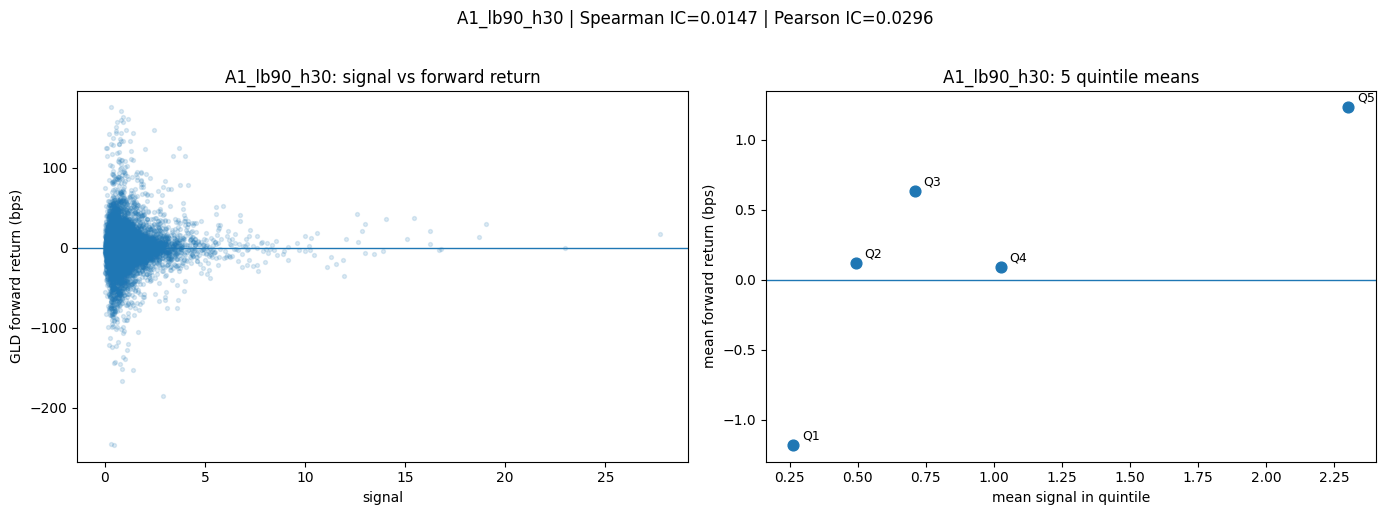

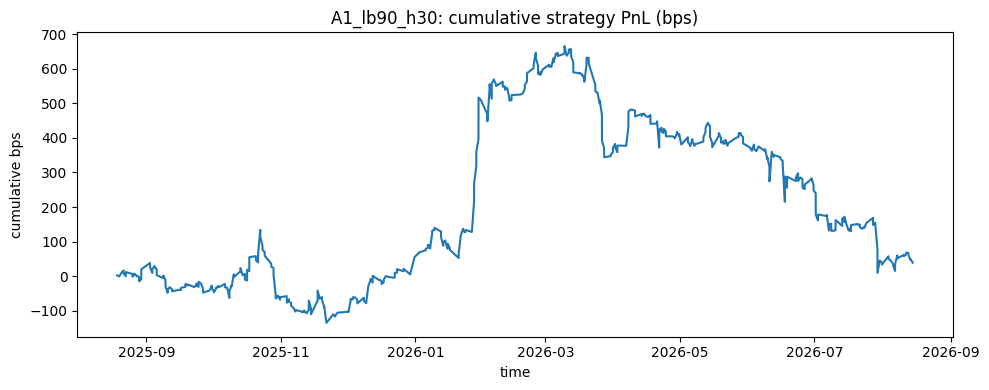

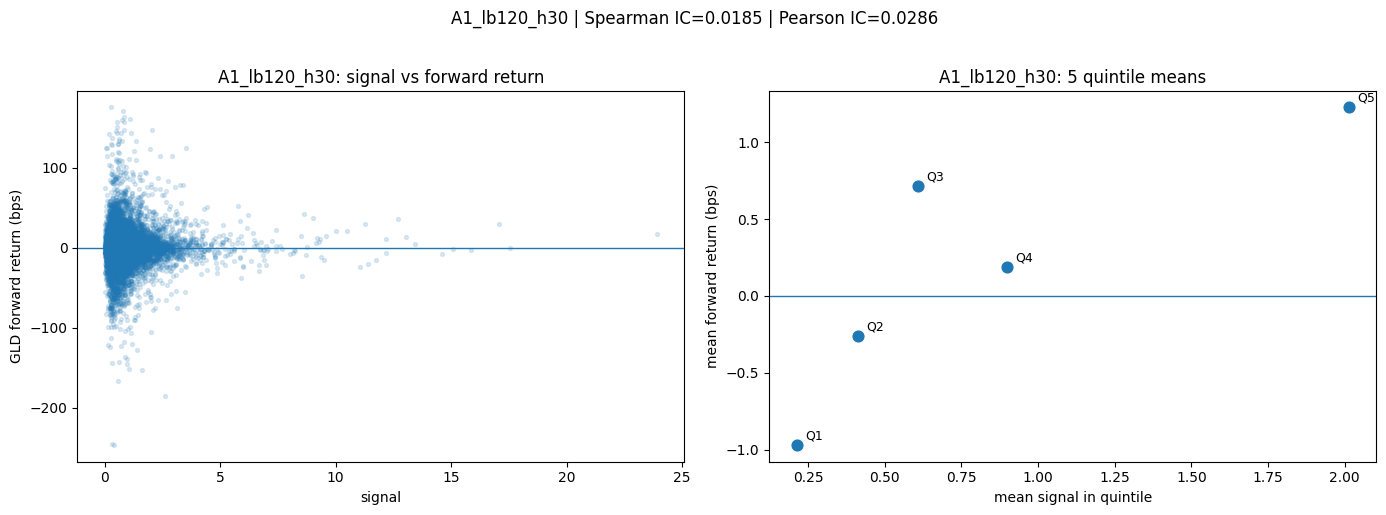

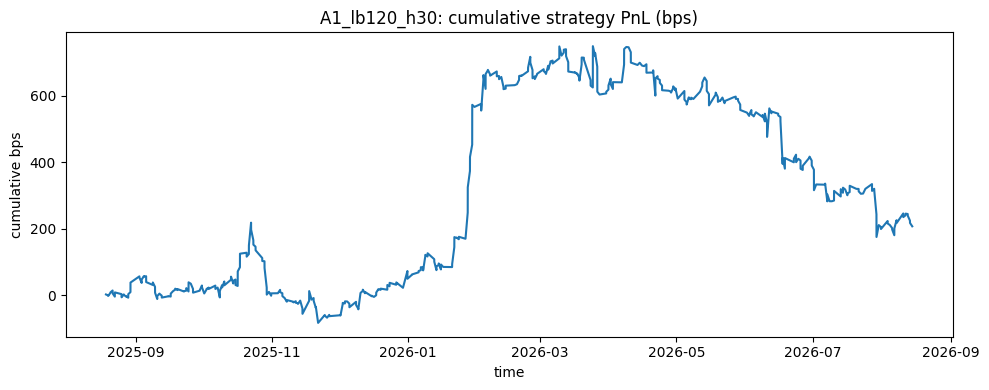

In [36]:
for cid, col in a1_selected:
    sample, trades = a1_eval_data[cid]
    plot_candidate_diagnostics(cid, sample, trades)


#### A.1 interpretation

**Signal screen:** Preferred lookback changes by session. On the close 30-minute GLD horizon, 90m and 120m clearly beat the 30m baseline (IC ~0.030 / ~0.029 vs ~0.017).

**Strategy diagnostic:** Under the provisional top-quintile long-only rule, 120m is stronger than baseline (~0.46 vs ~0.12 avg bps/trade), while 90m is similar to or slightly weaker than baseline (~0.08). IC ranking and strategy ranking therefore agree only partly.

**Survivors:** Carry both 90m and 120m as close-session lookback alternatives; keep 30m as the baseline comparator.


#### A.2 Expanding vs rolling normalization

Hold the baseline construction fixed and ask only whether the normalization should be expanding or rolling.

Fixed pieces:
- volume lookback = 30 minutes
- rolling volume mean uses min_periods = 5
- normalization uses min_periods = 30
- session = Close (15:00-16:00)
- horizons = 1 / 5 / 10 / 30 minutes

Raw ratio:

`raw = GC volume this minute / mean GC volume over the prior 30 minutes`

Then:
- expanding: divide by the mean of all past abs(raw)
- rolling: divide by the mean of only the previous K abs(raw) values

Rolling windows used: 60, 390, 1950
- 60 = about 1 hour (short)
- 390 = about one cash equity day (medium)
- 1950 = about five cash equity days (longer)

In [37]:
# fixed 30-minute raw ratio (same construction as baseline)
prior_mean_30 = (
    data["GC_volume"]
    .shift(1)
    .rolling(window=30, min_periods=5)
    .mean()
)

raw_30 = data["GC_volume"] / prior_mean_30

# expanding normalization (baseline style)
data["GC_signal_expanding"] = raw_30 / (
    raw_30.abs()
    .expanding(min_periods=30)
    .mean()
    .shift(1)
)

# rolling normalization for a small set of windows
rolling_windows = [60, 390, 1950]

for k in rolling_windows:
    data[f"GC_signal_rollnorm_{k}"] = raw_30 / (
        raw_30.abs()
        .rolling(window=k, min_periods=30)
        .mean()
        .shift(1)
    )

In [38]:
# close-window IC: expanding vs rolling normalization
norm_labels = ["expanding"] + [f"rollnorm_{k}" for k in rolling_windows]
norm_results = []

for label in norm_labels:
    signal_col = f"GC_signal_{label}"

    for h in horizons:
        temp = data[
            (data["Time"].dt.time >= time(15, 0)) &
            (data["Time"].dt.time < time(16, 0))
        ][
            [signal_col, f"GLD_fwd_{h}m"]
        ].dropna()

        ic = temp[signal_col].corr(temp[f"GLD_fwd_{h}m"])

        norm_results.append({
            "normalization": label,
            "horizon": h,
            "IC": ic,
            "n_obs": len(temp)
        })

norm_results = pd.DataFrame(norm_results)

norm_ic_matrix = norm_results.pivot(
    index="normalization",
    columns="horizon",
    values="IC"
).reindex(norm_labels)

norm_ic_matrix

horizon,1,5,10,30
normalization,,,,
expanding,-0.003982,0.000964,0.004750,0.016617
rollnorm_60,-0.006443,-0.003475,-0.001318,0.007401
rollnorm_390,-0.004419,0.000090,0.003938,0.013870
rollnorm_1950,-0.003672,0.001158,0.005039,0.017248


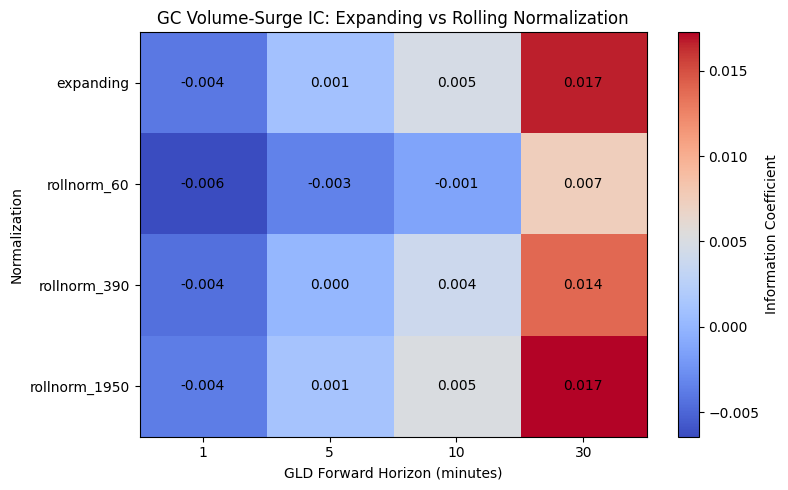

In [39]:
# heatmap of expanding vs rolling IC in the close window
plt.figure(figsize=(8, 5))

plt.imshow(
    norm_ic_matrix.values,
    aspect="auto",
    cmap="coolwarm"
)

plt.colorbar(label="Information Coefficient")

plt.xticks(
    range(len(norm_ic_matrix.columns)),
    norm_ic_matrix.columns
)

plt.yticks(
    range(len(norm_ic_matrix.index)),
    norm_ic_matrix.index
)

plt.xlabel("GLD Forward Horizon (minutes)")
plt.ylabel("Normalization")
plt.title("GC Volume-Surge IC: Expanding vs Rolling Normalization")

for i in range(len(norm_ic_matrix.index)):
    for j in range(len(norm_ic_matrix.columns)):
        plt.text(
            j,
            i,
            f"{norm_ic_matrix.iloc[i, j]:.3f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [40]:
# consistency check: A.2 expanding should match A.1 lookback=30 in the close window
a1_close_30 = (
    lookback_results[lookback_results["lookback"] == 30]
    [["horizon", "IC"]]
    .rename(columns={"IC": "A1_IC"})
)

a2_expanding = (
    norm_results[norm_results["normalization"] == "expanding"]
    [["horizon", "IC"]]
    .rename(columns={"IC": "A2_expanding_IC"})
)

consistency = a1_close_30.merge(a2_expanding, on="horizon")
consistency["difference"] = (
    consistency["A2_expanding_IC"] - consistency["A1_IC"]
)

consistency

,horizon,A1_IC,A2_expanding_IC,difference
0,1,-0.003982,-0.003982,0.0
1,5,0.000964,0.000964,0.0
2,10,0.004750,0.004750,0.0
3,30,0.016617,0.016617,0.0


#### A.2 candidate selection

A.2 is about second-stage normalization only (lookback fixed at 30).
Expanding is the baseline comparator (numeric only).
Rolling-1950 is the strongest rolling alternative and receives the full diagnostic package.


In [41]:
# compact IC comparison at 30m GLD horizon
a2_ic_compare = norm_ic_matrix[[30]].rename(columns={30: "pearson_ic_close"})
a2_ic_compare


horizon,pearson_ic_close
normalization,
expanding,0.016617
rollnorm_60,0.007401
rollnorm_390,0.013870
rollnorm_1950,0.017248


In [42]:
a2_metrics, a2_sample, a2_trades = candidate_metrics(
    "A2_rollnorm1950_h30",
    "GC_signal_rollnorm_1950",
    30,
)

pd.DataFrame([a2_metrics])


,candidate,horizon,pearson_ic,spearman_ic,avg_bps_per_trade,hit_rate,sharpe,sortino,n_trades,n_days,max_drawdown_bps
0,A2_rollnorm1950_h30,30,0.017248,-0.001212,0.105631,0.494759,0.102123,0.147292,477,245,-543.505064


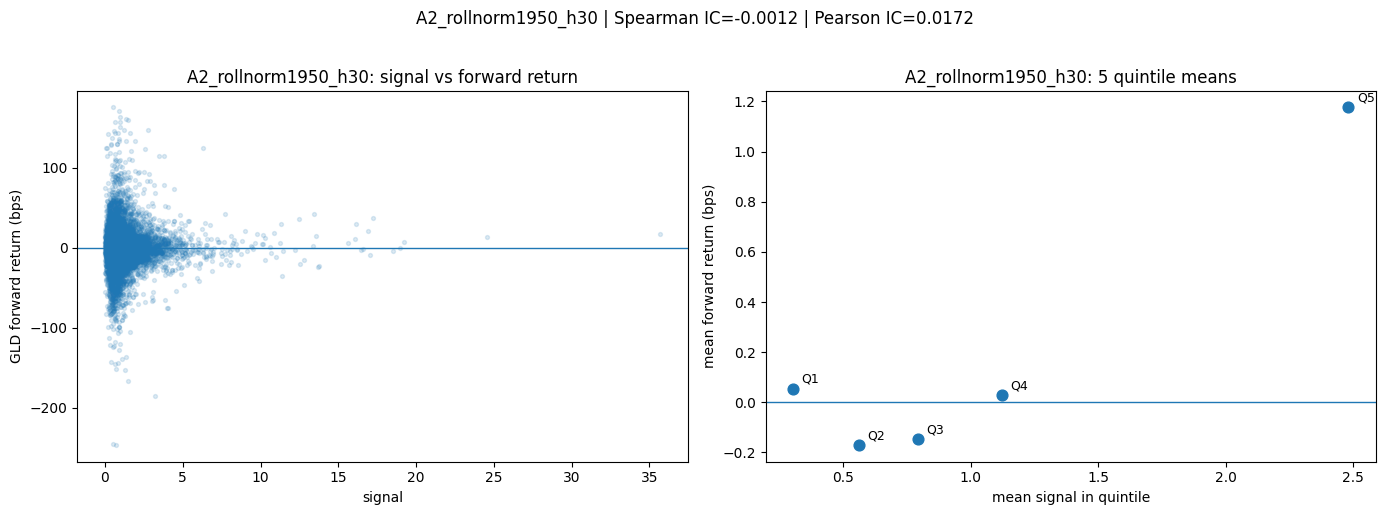

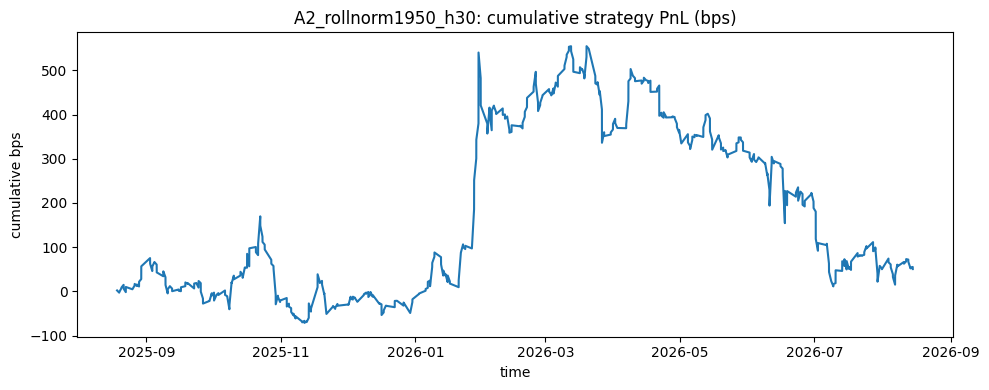

In [43]:
plot_candidate_diagnostics(
    "A2_rollnorm1950_h30",
    a2_sample,
    a2_trades,
)


#### A.2 interpretation

**Signal screen:** Short rolling norms are weaker. Rolling-1950 is only slightly above expanding at the 30m GLD horizon (IC ~0.0172 vs ~0.0166).

**Strategy diagnostic:** The improvement is small. Expanding remains a sensible default; rolling-1950 is a nearby alternative rather than a large upgrade.

**Survivor:** One A.2 candidate — rolling-1950 normalization (lookback fixed at 30).


### Section A - Conclusion

**Question:** Is the 30-minute lookback structurally preferred, or an artifact of the initial choice?

**What each subsection established**
- **A.1 (lookback / session):** On the close screen, longer lookbacks beat 30 minutes at the 30-minute GLD horizon (90m / 120m IC ~0.030 / ~0.029 vs baseline ~0.017). The open prefers a different pattern (mainly short-horizon relationships), so one fixed lookback is not structural across the day.
- **A.2 (normalization):** Expanding normalization remains adequate. Short rolling norms are weaker; rolling-1950 is only marginally above expanding (~0.0172 vs ~0.0166).

**Rejected / not special**
- Treating 30 minutes as uniquely preferred is not supported: it is a workable baseline, not the IC leader.
- Short rolling normalization does not deserve promotion.

**Surviving candidates**
- Baseline comparator: GC 30m lookback, expanding normalization, close session (full package shown once).
- A.1: 90m and 120m lookbacks at the 30-minute GLD horizon.
- A.2: rolling-1950 normalization as a nearby alternative to expanding.

**Decision:** 30 minutes looks like an **artifact of the initial choice**, not a structurally preferred lookback. Keep it as the documented baseline, but carry 90/120 (and optionally rolling-1950) into later joint tests. Signal-screen strength and provisional strategy P&L do not always rank the same way, so later work should keep both views separate.


### B. Volume ratio construction

*Which definition of unusual volume best predicts future GLD returns under fair evaluation?*

Controls held fixed in this section:
- local volume lookback = 30 minutes
- Close session = 15:00-16:00
- expanding normalization
- existing min_periods settings

We change the volume construction only. All four GLD horizons (1/5/10/30) are still evaluated.
Promising lookbacks from Section A are not re-swept here; they can be combined with B winners later.

#### B.1 Mean vs median

Compare current volume / prior 30-minute mean against current volume / prior 30-minute median.
Same expanding normalization afterward.

*Change is only made to rolling mean, making it rolling median, while expanding mean stays the same.*

In [44]:
# mean vs median raw ratios (30-minute lookback)
gc_prior_mean_30 = (
    data["GC_volume"]
    .shift(1)
    .rolling(window=30, min_periods=5)
    .mean()
)

gc_prior_median_30 = (
    data["GC_volume"]
    .shift(1)
    .rolling(window=30, min_periods=5)
    .median()
)

raw_mean = data["GC_volume"] / gc_prior_mean_30
raw_median = data["GC_volume"] / gc_prior_median_30

data["GC_signal_mean"] = raw_mean / (
    raw_mean.abs().expanding(min_periods=30).mean().shift(1)
)

data["GC_signal_median"] = raw_median / (
    raw_median.abs().expanding(min_periods=30).mean().shift(1)
)

In [45]:
# close-window IC comparison
mean_median_results = []

for label, col in [("mean", "GC_signal_mean"), ("median", "GC_signal_median")]:
    for h in horizons:
        temp = data[
            (data["Time"].dt.time >= time(15, 0)) &
            (data["Time"].dt.time < time(16, 0))
        ][[col, f"GLD_fwd_{h}m"]].dropna()

        mean_median_results.append({
            "construction": label,
            "horizon": h,
            "IC": temp[col].corr(temp[f"GLD_fwd_{h}m"]),
            "n_obs": len(temp)
        })

mean_median_results = pd.DataFrame(mean_median_results)

mean_median_ic = mean_median_results.pivot(
    index="construction",
    columns="horizon",
    values="IC"
)

mean_median_ic

horizon,1,5,10,30
construction,,,,
mean,-0.003982,0.000964,0.004750,0.016617
median,-0.003904,0.002552,0.004989,0.017526


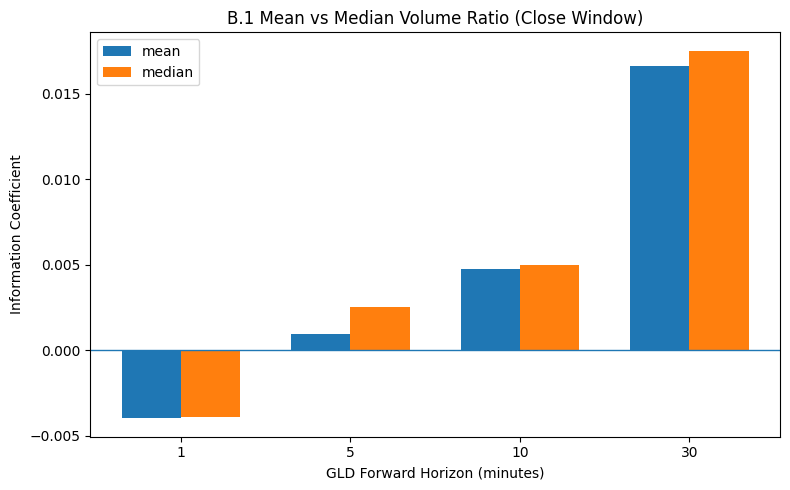

In [46]:
# simple bar comparison at each horizon
x = np.arange(len(horizons))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(
    x - width / 2,
    mean_median_ic.loc["mean", horizons].values,
    width,
    label="mean"
)
plt.bar(
    x + width / 2,
    mean_median_ic.loc["median", horizons].values,
    width,
    label="median"
)

plt.axhline(0, linewidth=1)
plt.xticks(x, horizons)
plt.xlabel("GLD Forward Horizon (minutes)")
plt.ylabel("Information Coefficient")
plt.title("B.1 Mean vs Median Volume Ratio (Close Window)")
plt.legend()
plt.tight_layout()
plt.show()

#### B.1 interpretation

**Signal screen:** Median is slightly above mean at every horizon, but the gap is small (30m IC ~0.0175 vs ~0.0166).

**Strategy diagnostic:** Under the provisional top-quintile rule at 30m, median (~0.07 avg bps/trade, Sharpe ~0.07) does **not** beat the baseline mean package (~0.12 avg bps/trade, Sharpe ~0.12).

**Candidate decision:** No new candidate from B.1.
The median tweak is not large enough on IC, and it does not improve the current strategy diagnostics over the existing baseline mean construction.


#### B.2 Percentile-rank construction

Is current GC volume high relative to the prior 30 one-minute volumes?
For each minute, the raw signal is the share of the prior 30 volumes that are below the current volume.
Then apply the same expanding normalization.

Same-time-of-day percentile (compare only to the same clock time on recent days) is a separate, more complex variant and is not built here.

In [47]:
# recent-history percentile rank vs prior 30 minutes
vol = data["GC_volume"].to_numpy()
pct_raw = np.full(len(vol), np.nan)

for i in range(len(vol)):
    hist = vol[max(0, i - 30):i]
    hist = hist[~np.isnan(hist)]

    if len(hist) < 5 or np.isnan(vol[i]):
        continue

    pct_raw[i] = np.mean(hist <= vol[i])

data["GC_pct_raw"] = pct_raw

data["GC_signal_pct"] = data["GC_pct_raw"] / (
    data["GC_pct_raw"].abs().expanding(min_periods=30).mean().shift(1)
)

In [48]:
# close-window IC
pct_results = []

for h in horizons:
    temp = data[
        (data["Time"].dt.time >= time(15, 0)) &
        (data["Time"].dt.time < time(16, 0))
    ][["GC_signal_pct", f"GLD_fwd_{h}m"]].dropna()

    pct_results.append({
        "construction": "percentile_30",
        "horizon": h,
        "IC": temp["GC_signal_pct"].corr(temp[f"GLD_fwd_{h}m"]),
        "n_obs": len(temp)
    })

pct_results = pd.DataFrame(pct_results)
pct_results

,construction,horizon,IC,n_obs
0,percentile_30,1,0.002837,14653
1,percentile_30,5,0.000562,14653
2,percentile_30,10,0.007209,14651
3,percentile_30,30,0.017110,14609


`percentile_30`: 30-minute recent-history percentile construction

#### B.2 candidate selection

Percentile is compared numerically to mean/median below. It does not receive a full diagnostic package.


In [49]:
# compact comparison vs prior constructions (numeric only)
b2_ic_compare = pd.DataFrame({
    "construction": ["baseline_mean", "median", "percentile"],
    "horizon": [30, 30, 30],
    "pearson_ic": [
        mean_median_ic.loc["mean", 30],
        mean_median_ic.loc["median", 30],
        pct_results.loc[pct_results["horizon"] == 30, "IC"].iloc[0],
    ],
})

b2_ic_compare


,construction,horizon,pearson_ic
0,baseline_mean,30,0.016617
1,median,30,0.017526
2,percentile,30,0.017110


#### B.2 interpretation

**Signal screen:** At the 30-minute GLD horizon, percentile IC (~0.0171) is essentially tied with / slightly above mean (~0.0166) and slightly below median (~0.0175). It is not a clear improvement.

**Candidate decision:** No new candidate from B.2.
Percentile does not justify a separate full package; mean/median already cover the unsigned-ratio family more cleanly.


#### B.3 Linear ratio vs log-ratio

Compare the linear mean ratio with log(current / prior 30-minute mean).
Invalid or non-positive inputs are set to NaN so they drop out of the IC.

In [50]:
# linear vs log ratio (same prior mean)
# raw_mean already exists from B.1

raw_log = np.log(data["GC_volume"] / gc_prior_mean_30)
raw_log = raw_log.replace([np.inf, -np.inf], np.nan)
raw_log = raw_log.where(
    (data["GC_volume"] > 0) & (gc_prior_mean_30 > 0)
)

data["GC_signal_log"] = raw_log / (
    raw_log.abs().expanding(min_periods=30).mean().shift(1)
)

# linear already stored as GC_signal_mean

In [51]:
# close-window IC
log_results = []

for label, col in [("linear_mean", "GC_signal_mean"), ("log_mean", "GC_signal_log")]:
    for h in horizons:
        temp = data[
            (data["Time"].dt.time >= time(15, 0)) &
            (data["Time"].dt.time < time(16, 0))
        ][[col, f"GLD_fwd_{h}m"]].dropna()

        log_results.append({
            "construction": label,
            "horizon": h,
            "IC": temp[col].corr(temp[f"GLD_fwd_{h}m"]),
            "n_obs": len(temp)
        })

log_results = pd.DataFrame(log_results)

log_ic = log_results.pivot(
    index="construction",
    columns="horizon",
    values="IC"
)

log_ic

horizon,1,5,10,30
construction,,,,
linear_mean,-0.003982,0.000964,0.004750,0.016617
log_mean,0.000121,0.001168,0.008696,0.012727


#### B.3 interpretation

**Signal screen:** Log-ratio does not improve on the linear mean ratio at the useful close horizons (30m IC ~0.013 vs ~0.017).

**Candidate decision:** No new candidate from B.3.
Keep the linear mean-ratio construction; do not carry a log-ratio package.


#### B.4 Total vs uptick vs downtick volume

Build the same 30-minute mean-ratio + expanding-normalization surge on:
- GC_volume
- GC_uptick_volume
- GC_downtick_volume

In [52]:
# total / uptick / downtick surge signals
tick_fields = {
    "total": "GC_volume",
    "uptick": "GC_uptick_volume",
    "downtick": "GC_downtick_volume",
}

for label, col in tick_fields.items():
    prior = (
        data[col]
        .shift(1)
        .rolling(window=30, min_periods=5)
        .mean()
    )
    raw = data[col] / prior
    data[f"GC_signal_{label}"] = raw / (
        raw.abs().expanding(min_periods=30).mean().shift(1)
    )

In [53]:
# close-window IC
tick_results = []

for label in tick_fields:
    col = f"GC_signal_{label}"

    for h in horizons:
        temp = data[
            (data["Time"].dt.time >= time(15, 0)) &
            (data["Time"].dt.time < time(16, 0))
        ][[col, f"GLD_fwd_{h}m"]].dropna()

        tick_results.append({
            "construction": label,
            "horizon": h,
            "IC": temp[col].corr(temp[f"GLD_fwd_{h}m"]),
            "n_obs": len(temp)
        })

tick_results = pd.DataFrame(tick_results)

tick_ic = tick_results.pivot(
    index="construction",
    columns="horizon",
    values="IC"
)

tick_ic

horizon,1,5,10,30
construction,,,,
downtick,-0.020735,-0.002922,-0.001572,0.010093
total,-0.003982,0.000964,0.004750,0.016617
uptick,0.035301,0.009585,0.016749,0.015666


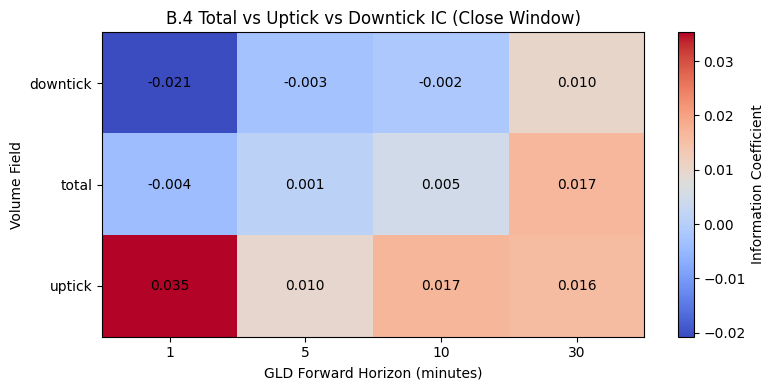

In [54]:
# heatmap for tick constructions
plt.figure(figsize=(8, 4))

plt.imshow(tick_ic.values, aspect="auto", cmap="coolwarm")
plt.colorbar(label="Information Coefficient")

plt.xticks(range(len(tick_ic.columns)), tick_ic.columns)
plt.yticks(range(len(tick_ic.index)), tick_ic.index)

plt.xlabel("GLD Forward Horizon (minutes)")
plt.ylabel("Volume Field")
plt.title("B.4 Total vs Uptick vs Downtick IC (Close Window)")

for i in range(len(tick_ic.index)):
    for j in range(len(tick_ic.columns)):
        plt.text(
            j, i,
            f"{tick_ic.iloc[i, j]:.3f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

#### B.4 candidate selection

Uptick dominates total and downtick on the close IC screen.
Strongest single specification: **GC uptick @ 1-minute GLD horizon** (IC ~0.035).
Other uptick horizons are weaker and not close enough to justify a second package.
Total and downtick are not carried forward.


In [55]:
# compact screen reminder (uptick only selected)
b4_ic_compare = tick_ic.copy()
b4_ic_compare


horizon,1,5,10,30
construction,,,,
downtick,-0.020735,-0.002922,-0.001572,0.010093
total,-0.003982,0.000964,0.004750,0.016617
uptick,0.035301,0.009585,0.016749,0.015666


In [56]:
b4_metrics, b4_sample, b4_trades = candidate_metrics(
    "B4_uptick_h1",
    "GC_signal_uptick",
    1,
)

pd.DataFrame([b4_metrics])


,candidate,horizon,pearson_ic,spearman_ic,avg_bps_per_trade,hit_rate,sharpe,sortino,n_trades,n_days,max_drawdown_bps
0,B4_uptick_h1,1,0.035301,0.100261,0.502709,0.58376,5.331183,8.261305,2931,245,-114.860109


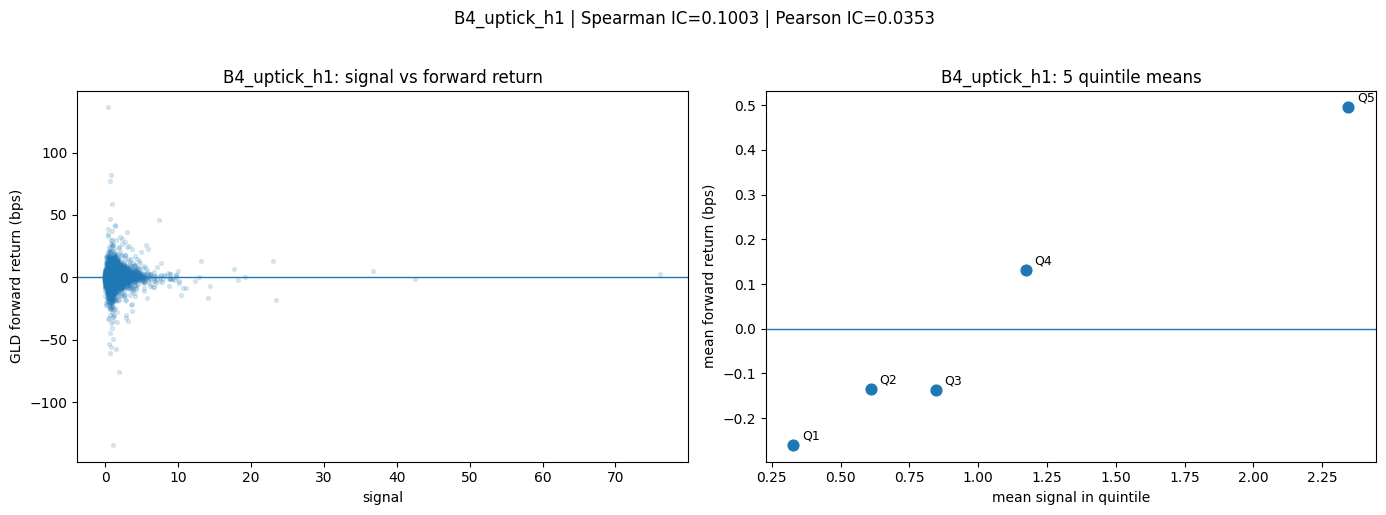

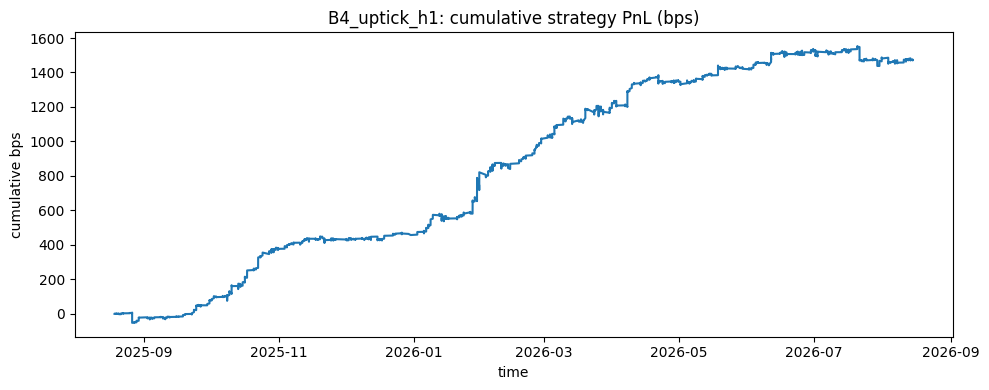

In [57]:
plot_candidate_diagnostics(
    "B4_uptick_h1",
    b4_sample,
    b4_trades,
)


#### B.4 interpretation

**Signal screen:** Uptick is clearly stronger than total or downtick, especially at 1m (IC ~0.035 vs total ~-0.004 / downtick ~-0.021).

**Strategy diagnostic:** Under the provisional rule, `B4_uptick_h1` is the strongest Section B package so far (~0.50 avg bps/trade, hit rate ~58%, Sharpe ~5.3, Sortino ~8.3).

**Survivor:** One candidate - GC uptick surge at the 1-minute GLD horizon.


#### B.5 Instrument sets

One-axis screen of activity sources under fixed controls:
- local lookback = 30 minutes (mean denominator)
- expanding normalization
- Close session (15:00-16:00)
- GLD forward horizons 1/5/10/30

**Equity symbols used for the ETF basket:** GLD, GLDM, IAU, IAUM
(verified from `equity_60.csv`).

**ETF basket activity (simple unweighted sum of traded volume):**

`ETF_basket_volume = sum(vwap_traded_volume across GLD, GLDM, IAU, IAUM at each Time)`

GLD remains the prediction target and is kept as its own minute panel.
ETF activity is aggregated separately by Time, then merged — so GLD rows are not duplicated.

**GC + MGC ounce-equivalent:**

`GC_volume * 100 + MGC_volume * 10`

**Futures / ETF cross-ratio:** `GC_volume / ETF_basket_volume`, then the same surge transform.


In [58]:
# verify ETF symbols in the loaded equity file
print("Equity symbols:")
print(equity["symbol"].value_counts())

etf_symbols = ["GLD", "GLDM", "IAU", "IAUM"]
missing = [s for s in etf_symbols if s not in set(equity["symbol"].unique())]
print("Missing basket symbols:", missing if missing else "none")


Equity symbols:
symbol
GLD     233392
IAU     210042
GLDM    199144
IAUM    160776
Name: count, dtype: int64


Missing basket symbols: none


In [59]:
# ETF basket activity: aggregate by Time only (do not expand the GLD target panel)
etf_activity = (
    equity[equity["symbol"].isin(etf_symbols)]
    .groupby("Time", as_index=False)
    .agg(ETF_basket_volume=("vwap_traded_volume", "sum"))
)

# drop prior ETF basket column if re-running this cell
if "ETF_basket_volume" in data.columns:
    data = data.drop(columns=["ETF_basket_volume"])

# merge minute-level ETF basket into the existing GLD+futures panel
data = pd.merge(data, etf_activity, on="Time", how="left")

# ounce-equivalent futures activity
data["GC_oz"] = data["GC_volume"] * 100
data["MGC_oz"] = data["MGC_volume"] * 10
data["GC_MGC_oz"] = data["GC_oz"] + data["MGC_oz"]

# futures / ETF basket cross-ratio level
data["GC_over_ETF"] = data["GC_volume"] / data["ETF_basket_volume"]

print("data rows:", len(data), "| unique Times:", data["Time"].nunique())
print("ETF_basket_volume null pct:", data["ETF_basket_volume"].isna().mean())


data rows: 233392 | unique Times: 233392
ETF_basket_volume null pct: 0.0


In [60]:
# B.5 instrument surge signals (same 30m mean + expanding norm)
instrument_fields = {
    "GC": "GC_volume",
    "MGC": "MGC_volume",
    "GC_MGC_oz": "GC_MGC_oz",
    "ETF_basket": "ETF_basket_volume",
    "GC_over_ETF": "GC_over_ETF",
}

for label, col in instrument_fields.items():
    prior = (
        data[col]
        .shift(1)
        .rolling(window=30, min_periods=5)
        .mean()
    )
    raw = data[col] / prior
    raw = raw.replace([np.inf, -np.inf], np.nan)
    data[f"signal_{label}"] = raw / (
        raw.abs().expanding(min_periods=30).mean().shift(1)
    )


In [61]:
# close-window IC screen
instrument_results = []

for label in instrument_fields:
    col = f"signal_{label}"

    for h in horizons:
        temp = data[
            (data["Time"].dt.time >= time(15, 0)) &
            (data["Time"].dt.time < time(16, 0))
        ][[col, f"GLD_fwd_{h}m"]].dropna()

        instrument_results.append({
            "construction": label,
            "horizon": h,
            "IC": temp[col].corr(temp[f"GLD_fwd_{h}m"]),
            "n_obs": len(temp),
        })

instrument_results = pd.DataFrame(instrument_results)

instrument_ic = instrument_results.pivot(
    index="construction",
    columns="horizon",
    values="IC",
).reindex(list(instrument_fields.keys()))

instrument_ic


horizon,1,5,10,30
construction,,,,
GC,-0.003982,0.000964,0.004750,0.016617
MGC,-0.007394,0.003395,0.008916,0.014011
GC_MGC_oz,-0.004586,-0.000433,0.006680,0.016358
ETF_basket,0.011531,0.010153,0.008676,0.013819
GC_over_ETF,0.002091,-0.005174,-0.003753,0.005016


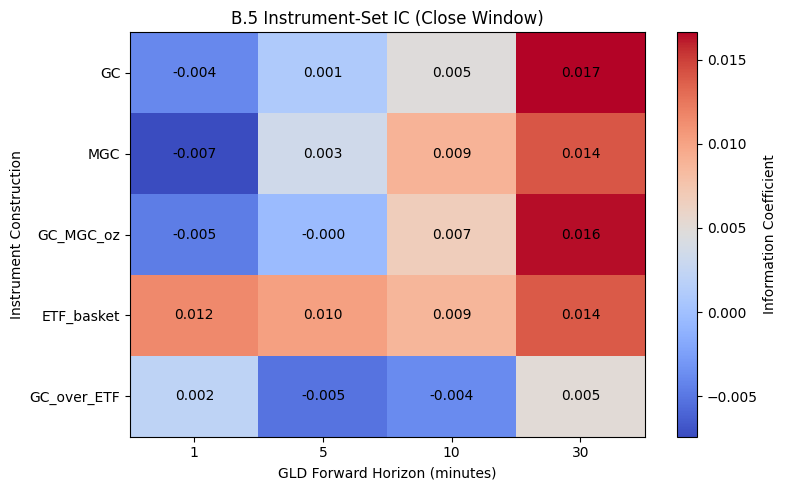

In [62]:
# heatmap of the B.5 instrument IC screen
plt.figure(figsize=(8, 5))

plt.imshow(instrument_ic.values, aspect="auto", cmap="coolwarm")
plt.colorbar(label="Information Coefficient")

plt.xticks(range(len(instrument_ic.columns)), instrument_ic.columns)
plt.yticks(range(len(instrument_ic.index)), instrument_ic.index)

plt.xlabel("GLD Forward Horizon (minutes)")
plt.ylabel("Instrument Construction")
plt.title("B.5 Instrument-Set IC (Close Window)")

for i in range(len(instrument_ic.index)):
    for j in range(len(instrument_ic.columns)):
        plt.text(
            j, i,
            f"{instrument_ic.iloc[i, j]:.3f}",
            ha="center",
            va="center",
        )

plt.tight_layout()
plt.show()


#### B.5 interpretation

**Signal screen:**
- GC @ 30m IC ~0.017 remains the strongest unsigned futures construction in this axis.
- GC+MGC ounce-equivalent is nearly identical to GC (~0.016).
- MGC alone is similar but not better.
- ETF basket is positive (short horizons ~0.01; 30m ~0.014) but does not beat GC at 30m and is weaker than B.4 uptick.
- GC / ETF cross-ratio is weak.

**Candidate decision:** No new candidate from B.5.
GC is already covered by the baseline package. None of the instrument variants improves enough to earn its own diagnostic package under this one-axis screen.


### Section B - Conclusion

**Question:** Which definition of unusual volume best predicts future GLD returns under fair evaluation?

**What each subsection established**
- **B.1 (mean vs median):** Median is only slightly above mean on IC (30m ~0.0175 vs ~0.0166) and does **not** beat the baseline mean under the provisional strategy rule (~0.07 vs ~0.12 avg bps/trade). No new candidate.
- **B.2 (percentile):** Percentile is roughly tied with mean/median on IC (~0.017) and is not a clear improvement. No new candidate.
- **B.3 (log-ratio):** Log compression weakens the useful-horizon IC (30m ~0.013 vs linear ~0.017). No new candidate.
- **B.4 (total / uptick / downtick):** Uptick is the standout. At 1m its IC (~0.035) dominates total and downtick, and the provisional strategy package is strongly positive (~0.50 avg bps/trade, hit ~58%).
- **B.5 (instruments / ETF basket):** With GLD+GLDM+IAU+IAUM available, an unweighted ETF-basket volume sum was tested alongside GC, MGC, GC+MGC ounces, and GC/ETF. None improved meaningfully on baseline GC mean-ratio. No new candidate.

**Rejected**
- Median, percentile, and log-ratio as replacements for the linear mean denominator.
- Total and downtick volume as primary surge sources.
- MGC-only, GC+MGC, ETF basket, and GC/ETF cross-ratio as standalone instrument upgrades under the fixed 30m mean-ratio screen.

**Surviving Section B candidate**
- `B4_uptick_h1`: GC uptick-volume surge, 30-minute local lookback, expanding normalization, close session, 1-minute GLD horizon.

Baseline GC total-volume mean-ratio @ 30m remains the common comparator (full package shown once earlier).

**Decision / takeaway:** Under fair one-axis evaluation, the best *definition of unusual volume* in this section is **directional uptick intensity**, not a different unsigned ratio transform. Most unsigned-ratio variants (median, percentile, log, ETF basket) are incremental or flat versus the baseline mean ratio. The consequence for later research is to treat uptick as the primary Section B survivor when combining with promising Section A lookbacks/normalizations - not to expand the unsigned-ratio family further without new evidence.


### C. Velocity / acceleration and burst timing

**Question:** Does predictive information come from volume surge simply being elevated, or from the burst building, accelerating, persisting, or fading?

One-axis experiment. Control = original static GC total-volume baseline:
- `S_t = GC_signal_30`
- 30-bar prior rolling mean, expanding normalization
- Close 15:00-16:00
- GLD horizons 1 / 5 / 10 / 30

Do not mix A lookback winners, B uptick, MGC, or ETF constructions into this section.


#### C.1 Velocity / acceleration

**Question:** Does the *change* in static volume surge contain more predictive information than the *level* of static surge?

**Definitions (economic meaning)**
- **Static** `S_t`: how elevated the surge currently is
- **Positive velocity**: surge is building
- **Negative velocity**: surge is cooling
- **Positive acceleration**: the build-up itself is strengthening
- **Negative acceleration**: the build-up is slowing or reversing

**Velocity at lag k**

`V_t(k) = S_t - S_(t-k)` for k = 1, 5, 15 minutes.

**Acceleration as change in velocity**

`A_t(k) = V_t(k) - V_(t-k)(k)`

So:
- `acc_1  = (S_t - S_(t-1)) - (S_(t-1) - S_(t-2))`
- `acc_5  = (S_t - S_(t-5)) - (S_(t-5) - S_(t-10))`
- `acc_15 = (S_t - S_(t-15)) - (S_(t-15) - S_(t-30))`

Lags are computed on the full time-ordered minute panel *before* the close-window filter.
A lag is used only when the prior bar is on the same date and exactly k minutes earlier (no day-boundary / gap bridging).


In [63]:
# C.1 features from static surge (full panel, then screen in close window)
S = data["GC_signal_30"]

def valid_k_lag(k):
    """True when the k-bar lag is same-date and exactly k minutes earlier."""
    return (
        (data["Time"] - data["Time"].shift(k) == pd.Timedelta(minutes=k)) &
        (data["date"] == data["date"].shift(k))
    )

ok1 = valid_k_lag(1)
ok2 = valid_k_lag(2)
ok5 = valid_k_lag(5)
ok10 = valid_k_lag(10)
ok15 = valid_k_lag(15)
ok30 = valid_k_lag(30)

# velocity
data["surge_vel_1"] = np.where(ok1, S - S.shift(1), np.nan)
data["surge_vel_5"] = np.where(ok5, S - S.shift(5), np.nan)
data["surge_vel_15"] = np.where(ok15, S - S.shift(15), np.nan)

# acceleration = change in same-lag velocity
data["surge_acc_1"] = np.where(
    ok1 & ok2,
    data["surge_vel_1"] - data["surge_vel_1"].shift(1),
    np.nan,
)
data["surge_acc_5"] = np.where(
    ok5 & ok10,
    data["surge_vel_5"] - data["surge_vel_5"].shift(5),
    np.nan,
)
data["surge_acc_15"] = np.where(
    ok15 & ok30,
    data["surge_vel_15"] - data["surge_vel_15"].shift(15),
    np.nan,
)


In [64]:
# C.1 IC screen: Pearson + Spearman vs static
c1_signals = {
    "static": "GC_signal_30",
    "vel_1": "surge_vel_1",
    "vel_5": "surge_vel_5",
    "vel_15": "surge_vel_15",
    "acc_1": "surge_acc_1",
    "acc_5": "surge_acc_5",
    "acc_15": "surge_acc_15",
}

c1_rows = []
close_mask = (
    (data["Time"].dt.time >= time(15, 0)) &
    (data["Time"].dt.time < time(16, 0))
)

for label, col in c1_signals.items():
    for h in horizons:
        temp = data.loc[close_mask, [col, f"GLD_fwd_{h}m"]].dropna()
        c1_rows.append({
            "construction": label,
            "horizon": h,
            "pearson_ic": temp[col].corr(temp[f"GLD_fwd_{h}m"]),
            "spearman_ic": temp[col].corr(temp[f"GLD_fwd_{h}m"], method="spearman"),
            "n_obs": len(temp),
        })

c1_results = pd.DataFrame(c1_rows)

c1_pearson = c1_results.pivot(
    index="construction", columns="horizon", values="pearson_ic"
).reindex(list(c1_signals.keys()))

c1_spearman = c1_results.pivot(
    index="construction", columns="horizon", values="spearman_ic"
).reindex(list(c1_signals.keys()))

c1_n = c1_results.pivot(
    index="construction", columns="horizon", values="n_obs"
).reindex(list(c1_signals.keys()))

print("Pearson IC:")
display(c1_pearson)
print("Spearman IC:")
display(c1_spearman)
print("n_obs:")
display(c1_n)


Pearson IC:


horizon,1,5,10,30
construction,,,,
static,-0.003982,0.000964,0.004750,0.016617
vel_1,-0.014467,-0.006560,0.000133,0.000786
vel_5,-0.003411,-0.001005,-0.000011,-0.001864
vel_15,-0.008435,-0.002819,-0.000734,0.001000
acc_1,-0.016582,-0.006518,-0.001322,0.000064
acc_5,-0.003857,-0.003080,-0.002480,-0.004870
acc_15,-0.003100,-0.000543,-0.000047,0.001223


Spearman IC:


horizon,1,5,10,30
construction,,,,
static,0.006929,0.009340,0.004275,-0.000850
vel_1,0.002596,0.005540,0.000790,-0.004213
vel_5,0.005666,0.000072,0.004255,-0.008474
vel_15,0.000374,0.004900,0.008020,-0.005994
acc_1,-0.002808,0.001245,-0.006201,-0.004953
acc_5,-0.000721,-0.006480,0.000594,0.003885
acc_15,0.000566,0.001674,0.003428,0.000524


n_obs:


horizon,1,5,10,30
construction,,,,
static,14653,14653,14651,14609
vel_1,14626,14626,14624,14582
vel_5,14625,14625,14623,14581
vel_15,14619,14619,14617,14575
acc_1,14609,14609,14607,14565
acc_5,14606,14606,14604,14562
acc_15,14592,14592,14590,14548


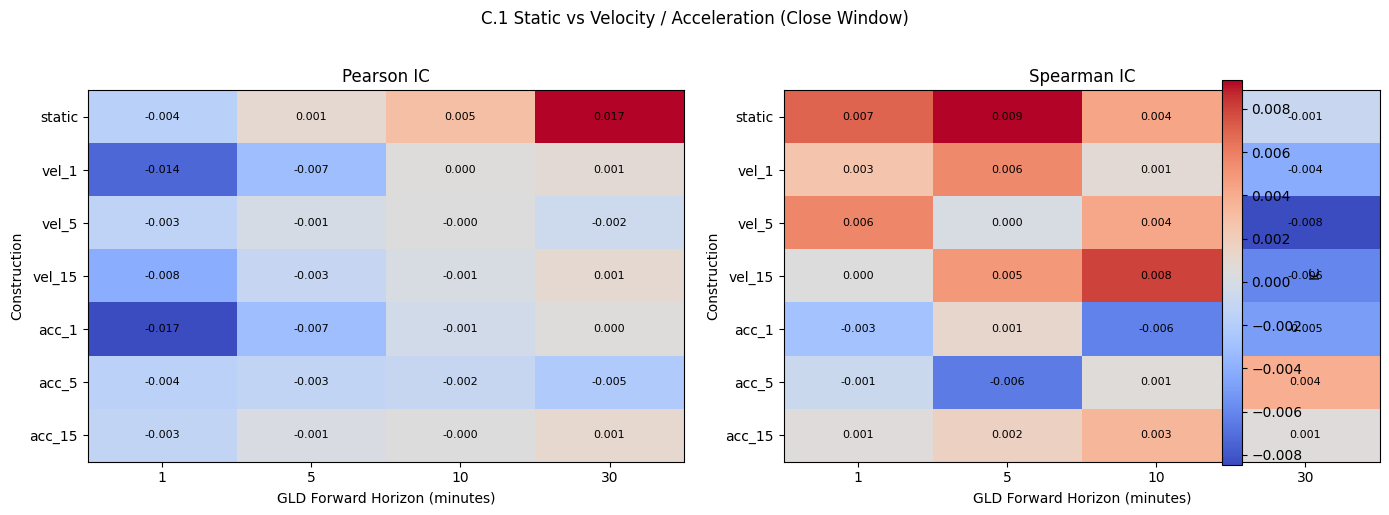

In [65]:
# C.1 heatmaps: Pearson and Spearman
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, matrix, title in [
    (axes[0], c1_pearson, "Pearson IC"),
    (axes[1], c1_spearman, "Spearman IC"),
]:
    im = ax.imshow(matrix.values, aspect="auto", cmap="coolwarm")
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns)
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index)
    ax.set_xlabel("GLD Forward Horizon (minutes)")
    ax.set_ylabel("Construction")
    ax.set_title(title)
    for i in range(len(matrix.index)):
        for j in range(len(matrix.columns)):
            ax.text(
                j, i,
                f"{matrix.iloc[i, j]:.3f}",
                ha="center",
                va="center",
                fontsize=8,
            )

fig.colorbar(im, ax=axes, fraction=0.03, pad=0.04, label="IC")
plt.suptitle(
    "C.1 Static vs Velocity / Acceleration (Close Window)",
    y=1.02,
)
plt.tight_layout()
plt.show()


#### C.1 interpretation

**Signal screen:** Static surge remains the strongest construction on the useful close horizons. At 30m, static Pearson IC is about 0.017 while velocity/acceleration Pearson ICs are near zero (roughly -0.005 to +0.001). Spearman ICs are similarly flat and do not favor vel/acc over static.

At short horizons, several velocity/acceleration Pearson ICs are *negative* (e.g. vel_1 and acc_1 at 1m), which is directionally consistent with "cooling / fading" rather than "building," but the magnitudes are small and they do not beat static as a usable alternative on this screen.

**Candidate decision:** No new candidate from C.1.

**Answer:** Velocity and acceleration do **not** improve on static surge under this one-axis close-window IC screen.


#### C.2 Duration above threshold before entry

**Question:** Once static surge first becomes unusually elevated, does waiting for it to remain elevated for N consecutive minutes before entering GLD improve subsequent returns?

**Fixed threshold (not optimized here):**
lagged expanding historical 80th percentile of `GC_signal_30`
(`expanding(...).quantile(0.80).shift(1)`).

The threshold itself is held fixed. C.2 varies only the amount of persistence required before entry.

**Burst definition**
- A burst begins when surge crosses above the historical threshold.
- A burst ends when surge is no longer above threshold, the trading date changes, or timestamps are not consecutive 1-minute observations.

**Entry rules (one entry per burst when confirmation is first reached)**
- 1-bar: enter at streak == 1 (immediate / onset)
- 2-bar: enter only when streak first reaches 2
- 3-bar: enter only when streak first reaches 3
- 4-bar: enter only when streak first reaches 4

If a burst stays elevated for 8 minutes, each rule still contributes at most one entry (at the moment confirmation is first met). This is *waiting before entry*, not trading every minute of a persistent state.


In [66]:
# C.2: causal threshold + gap/date-aware streak + first-hit confirmation entries
surge_thresh = (
    data["GC_signal_30"]
    .expanding(min_periods=50)
    .quantile(0.80)
    .shift(1)
)

above_thresh = (data["GC_signal_30"] > surge_thresh) & surge_thresh.notna()

consecutive_1m = (
    (data["Time"] - data["Time"].shift(1) == pd.Timedelta(minutes=1)) &
    (data["date"] == data["date"].shift(1))
)

streak = np.zeros(len(data), dtype=float)
run = 0

for i in range(len(data)):
    if not bool(above_thresh.iloc[i]):
        run = 0
        streak[i] = 0.0
        continue

    # new burst if first bar, date/gap break, or previous bar was not elevated
    if i == 0 or (not bool(consecutive_1m.iloc[i])) or run == 0:
        run = 1
    else:
        run += 1

    streak[i] = run

data["surge_thresh"] = surge_thresh
data["surge_above"] = above_thresh.astype(float)
data["surge_streak"] = streak

# one entry when confirmation duration is FIRST reached
for n in [1, 2, 3, 4]:
    data[f"confirm_{n}"] = (data["surge_streak"] == n).astype(float)


In [67]:
# C.2 screen: mean fwd bps, hit rate, counts at first confirmation
c2_rows = []

for n in [1, 2, 3, 4]:
    entry = data[f"confirm_{n}"] == 1
    for h in horizons:
        vals = data.loc[close_mask & entry, f"GLD_fwd_{h}m_bps"].dropna()
        c2_rows.append({
            "confirm_bars": n,
            "horizon": h,
            "mean_fwd_bps": vals.mean(),
            "hit_rate": (vals > 0).mean() if len(vals) else np.nan,
            "n_entries": len(vals),
        })

c2_results = pd.DataFrame(c2_rows)

c2_mean = c2_results.pivot(
    index="confirm_bars", columns="horizon", values="mean_fwd_bps"
)
c2_hit = c2_results.pivot(
    index="confirm_bars", columns="horizon", values="hit_rate"
)
c2_n = c2_results.pivot(
    index="confirm_bars", columns="horizon", values="n_entries"
)

print("Mean GLD forward return (bps) at first confirmation:")
display(c2_mean)
print("Hit rate:")
display(c2_hit)
print("Eligible entry counts:")
display(c2_n)


Mean GLD forward return (bps) at first confirmation:


horizon,1,5,10,30
confirm_bars,,,,
1,0.089104,-0.095030,0.155839,0.620319
2,-0.058352,0.060580,0.370837,1.155570
3,0.132717,0.174656,0.247992,1.234782
4,0.476118,1.846551,1.519091,3.936949


Hit rate:


horizon,1,5,10,30
confirm_bars,,,,
1,0.516484,0.503497,0.501249,0.487462
2,0.503077,0.523077,0.540000,0.514683
3,0.508961,0.526882,0.526882,0.519856
4,0.530769,0.538462,0.538462,0.573643


Eligible entry counts:


horizon,1,5,10,30
confirm_bars,,,,
1,2002,2002,2001,1994
2,650,650,650,647
3,279,279,279,277
4,130,130,130,129


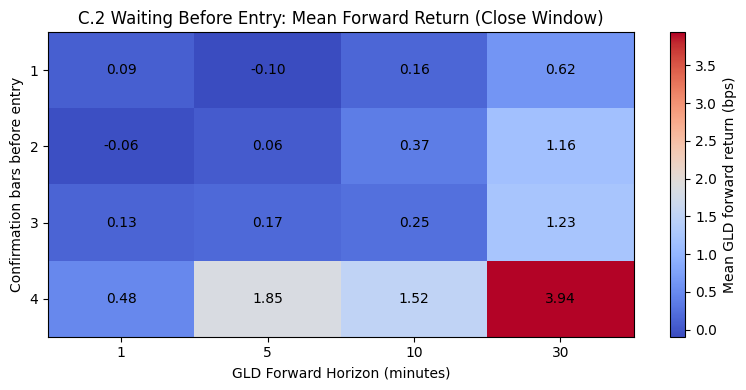

In [68]:
# heatmap: confirmation duration x horizon (mean fwd bps)
plt.figure(figsize=(8, 4))

plt.imshow(c2_mean.values, aspect="auto", cmap="coolwarm")
plt.colorbar(label="Mean GLD forward return (bps)")

plt.xticks(range(len(c2_mean.columns)), c2_mean.columns)
plt.yticks(range(len(c2_mean.index)), c2_mean.index)

plt.xlabel("GLD Forward Horizon (minutes)")
plt.ylabel("Confirmation bars before entry")
plt.title("C.2 Waiting Before Entry: Mean Forward Return (Close Window)")

for i in range(len(c2_mean.index)):
    for j in range(len(c2_mean.columns)):
        plt.text(
            j, i,
            f"{c2_mean.iloc[i, j]:.2f}",
            ha="center",
            va="center",
        )

plt.tight_layout()
plt.show()


In [69]:
# categorical / event-entry diagnostics (no scatter/quintile)

def phase_entry_metrics(candidate_id, entry_mask, horizon):
    """Non-overlapping long-only metrics when entry_mask is true."""
    fwd = f"GLD_fwd_{horizon}m"
    fwd_bps = f"GLD_fwd_{horizon}m_bps"

    sample = data.loc[
        close_mask & entry_mask.fillna(False),
        ["Time", "date", fwd, fwd_bps],
    ].dropna().copy()

    sample = sample.rename(columns={
        fwd: "fwd_return",
        fwd_bps: "fwd_return_bps",
    })
    sample["position"] = 1.0

    trades = build_nonoverlapping_trades(sample, horizon)

    if len(trades) == 0:
        metrics = {
            "candidate": candidate_id,
            "horizon": horizon,
            "pearson_ic": np.nan,
            "spearman_ic": np.nan,
            "avg_bps_per_trade": np.nan,
            "hit_rate": np.nan,
            "sharpe": np.nan,
            "sortino": np.nan,
            "n_trades": 0,
            "n_days": 0,
            "max_drawdown_bps": np.nan,
        }
        return metrics, sample, trades

    daily = trades.groupby("date")["strategy_return"].sum()
    daily_mean = daily.mean()
    daily_std = daily.std(ddof=1)
    downside = daily[daily < 0]
    downside_std = downside.std(ddof=1) if len(downside) > 1 else np.nan

    sharpe = (
        (daily_mean / daily_std) * np.sqrt(252)
        if daily_std and daily_std > 0 else np.nan
    )
    sortino = (
        (daily_mean / downside_std) * np.sqrt(252)
        if downside_std and downside_std > 0 else np.nan
    )

    bps = trades["strategy_return_bps"]
    metrics = {
        "candidate": candidate_id,
        "horizon": horizon,
        "pearson_ic": np.nan,
        "spearman_ic": np.nan,
        "avg_bps_per_trade": bps.mean(),
        "hit_rate": (bps > 0).mean(),
        "sharpe": sharpe,
        "sortino": sortino,
        "n_trades": len(trades),
        "n_days": trades["date"].nunique(),
        "max_drawdown_bps": (bps.cumsum() - bps.cumsum().cummax()).min(),
    }
    return metrics, sample, trades


def plot_phase_pnl(candidate_id, trades):
    """Cumulative PnL for a categorical entry rule."""
    if len(trades) == 0:
        print("No trades.")
        return

    trades = trades.sort_values("Time").copy()
    trades["cum_bps"] = trades["strategy_return_bps"].cumsum()

    plt.figure(figsize=(10, 4))
    plt.plot(trades["Time"], trades["cum_bps"])
    plt.title(f"{candidate_id}: cumulative strategy PnL (bps)")
    plt.ylabel("cumulative bps")
    plt.xlabel("time")
    plt.tight_layout()
    plt.show()


#### C.2 candidate selection

The confirmation screen shows a clear trade-off: longer waits raise mean forward bps at longer horizons while cutting entry counts sharply
(at 30m: 1-bar ~0.62 bps on 1994 entries; 2-bar ~1.16 on 647; 3-bar ~1.23 on 277; 4-bar ~3.94 on 129).

Immediate 1-bar entry is weak under non-overlapping 30m holds (provisional avg bps near zero / slightly negative).
Among confirmation rules, **4-bar confirmation at the 30-minute GLD horizon** is the strongest provisional screen result, but it is sparse.
One candidate is packaged at that definition; 1/2/3-bar rules are not.


In [70]:
c2_metrics, c2_sample, c2_trades = phase_entry_metrics(
    "C2_confirm4_h30",
    data["confirm_4"] == 1,
    30,
)

pd.DataFrame([c2_metrics])


,candidate,horizon,pearson_ic,spearman_ic,avg_bps_per_trade,hit_rate,sharpe,sortino,n_trades,n_days,max_drawdown_bps
0,C2_confirm4_h30,30,NaN,NaN,4.422007,0.582609,3.426639,9.110155,115,104,-100.672391


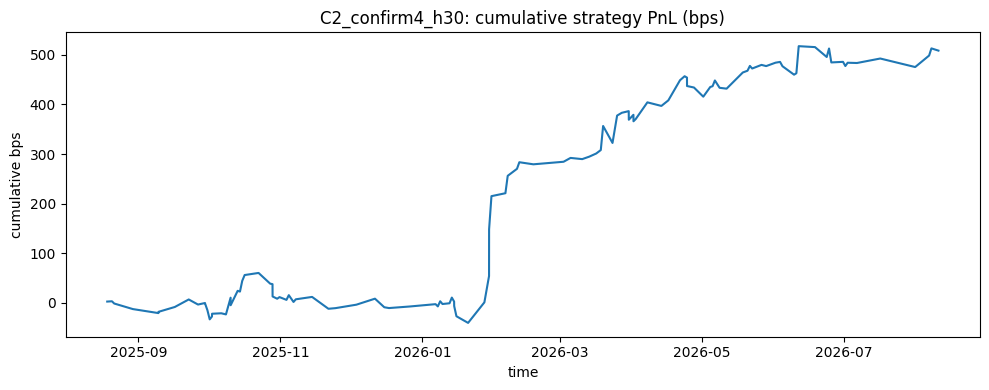

In [71]:
plot_phase_pnl("C2_confirm4_h30", c2_trades)


#### C.2 interpretation

**Entry-rule screen:** Waiting before entry improves conditional mean forward returns at longer horizons, at the cost of far fewer eligible bursts. 4-bar confirmation has the highest mean 30m forward bps (~3.94) among the tested rules, with the smallest entry count (129).

**Provisional strategy diagnostic:** Non-overlapping C2_confirm4_h30 shows ~4.42 avg bps/trade, hit ~58%, Sharpe ~3.43, Sortino ~9.11 on 115 trades across 104 days. This is a sparse provisional survivor, not a robustness claim.

**Survivor:** C2_confirm4_h30 - enter once when the static surge first completes 4 consecutive elevated minutes; hold 30 minutes.


#### C.3 Burst phase / entry timing

**Question:** Conditional on an elevated burst, is the better entry state onset, rising flank, ongoing persistence, or confirmed fade?

Distinct from C.2:
- C.2 asks *how long* to wait before entry (confirmation duration).
- C.3 asks *what phase* the burst is in (state diagnostic).

**Causal phase definitions**
- **Onset:** first above-threshold bar (`streak == 1`)
- **Rising flank:** elevated, already inside the burst (`streak >= 2`), and current surge > previous surge (onset excluded)
- **Persistence:** elevated with `streak >= 2` (broad ongoing-elevated state; overlaps rising flank and some fade bars)
- **Confirmed fade:** still elevated; previous bar was rising vs its predecessor; current surge has fallen from the previous bar

Overlap note: persistence is a broad elevated state. Rising flank and confirmed fade are mutually exclusive refinements inside elevated bursts; onset is separate.


In [72]:
# C.3 causal phase flags
s = data["GC_signal_30"]
rising = s > s.shift(1)
falling = s < s.shift(1)
was_rising = s.shift(1) > s.shift(2)
elevated = data["surge_above"] == 1

data["phase_onset"] = (data["surge_streak"] == 1).astype(float)
data["phase_rising_flank"] = (
    elevated & (data["surge_streak"] >= 2) & rising
).astype(float)
data["phase_persist"] = (data["surge_streak"] >= 2).astype(float)
data["phase_fade"] = (elevated & falling & was_rising).astype(float)


In [73]:
# C.3 screen: mean fwd bps and counts by phase
phase_masks = {
    "onset": data["phase_onset"] == 1,
    "rising_flank": data["phase_rising_flank"] == 1,
    "persist": data["phase_persist"] == 1,
    "fade": data["phase_fade"] == 1,
}

c3_rows = []

for label, mask in phase_masks.items():
    for h in horizons:
        vals = data.loc[close_mask & mask, f"GLD_fwd_{h}m_bps"].dropna()
        c3_rows.append({
            "phase": label,
            "horizon": h,
            "mean_fwd_bps": vals.mean(),
            "hit_rate": (vals > 0).mean() if len(vals) else np.nan,
            "n_obs": len(vals),
        })

c3_results = pd.DataFrame(c3_rows)

c3_mean = c3_results.pivot(
    index="phase", columns="horizon", values="mean_fwd_bps"
).reindex(list(phase_masks.keys()))

c3_hit = c3_results.pivot(
    index="phase", columns="horizon", values="hit_rate"
).reindex(list(phase_masks.keys()))

c3_n = c3_results.pivot(
    index="phase", columns="horizon", values="n_obs"
).reindex(list(phase_masks.keys()))

print("Mean GLD forward return (bps):")
display(c3_mean)
print("Hit rate:")
display(c3_hit)
print("Observation counts:")
display(c3_n)


Mean GLD forward return (bps):


horizon,1,5,10,30
phase,,,,
onset,0.089104,-0.095030,0.155839,0.620319
rising_flank,0.014931,0.166241,0.457096,1.759631
persist,0.192680,0.407180,0.695356,1.678222
fade,0.224733,0.316142,0.569203,0.856066


Hit rate:


horizon,1,5,10,30
phase,,,,
onset,0.516484,0.503497,0.501249,0.487462
rising_flank,0.517483,0.534965,0.529720,0.516696
persist,0.515691,0.528414,0.539440,0.523444
fade,0.508946,0.516899,0.544732,0.510978


Observation counts:


horizon,1,5,10,30
phase,,,,
onset,2002,2002,2001,1994
rising_flank,572,572,572,569
persist,1179,1179,1179,1173
fade,503,503,503,501


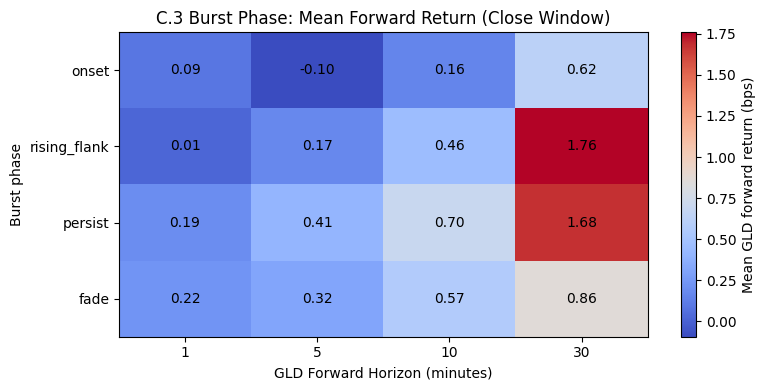

In [74]:
# C.3 heatmap: phase x horizon
plt.figure(figsize=(8, 4))

plt.imshow(c3_mean.values, aspect="auto", cmap="coolwarm")
plt.colorbar(label="Mean GLD forward return (bps)")

plt.xticks(range(len(c3_mean.columns)), c3_mean.columns)
plt.yticks(range(len(c3_mean.index)), c3_mean.index)

plt.xlabel("GLD Forward Horizon (minutes)")
plt.ylabel("Burst phase")
plt.title("C.3 Burst Phase: Mean Forward Return (Close Window)")

for i in range(len(c3_mean.index)):
    for j in range(len(c3_mean.columns)):
        plt.text(
            j, i,
            f"{c3_mean.iloc[i, j]:.2f}",
            ha="center",
            va="center",
        )

plt.tight_layout()
plt.show()


#### C.3 interpretation

**State screen:** At longer horizons, rising flank and ongoing persistence show higher mean forward bps than onset or confirmed fade
(at 30m: rising flank ~1.76, persist ~1.68, fade ~0.86, onset ~0.62).
Onset is the weakest longer-horizon state. Confirmed fade is positive but below persistence/rising.

**Relation to C.2:** This reinforces waiting past immediate onset. It does not introduce a distinct entry construction beyond the confirmation-duration rule already packaged in C.2.

**Candidate decision:** No new candidate from C.3.


### Section C - Conclusion

**Question:** Does velocity/acceleration improve on static surge, and does the evidence favor burst onset, persistence, or confirmed fade?

**What each subsection established**
- **C.1:** Changes in surge (velocity / acceleration) do not beat the static surge level on Pearson or Spearman IC in the close window. At 30m, static Pearson IC remains ~0.017 while vel/acc Pearson ICs are ~ -0.005 to +0.001. Short-horizon vel/acc Pearson ICs are often slightly negative (cooling/fade-consistent), but not enough to replace static. No new candidate.
- **C.2 (entry-confirmation):** Waiting for more consecutive elevated bars before entry raises conditional mean forward returns at longer horizons while cutting opportunity count. 4-bar confirmation at 30m is the strongest provisional rule among 1/2/3/4-bar alternatives (~3.94 mean fwd bps on 129 entries; non-overlapping package ~4.42 avg bps/trade on 115 trades / 104 days), but sparse.
- **C.3:** Conditional on an elevated burst, rising flank / persistence look better than onset or confirmed fade on mean forward bps. This agrees with C.2's preference for waiting past onset, without adding a separate packaged rule.

**Rejected**
- Velocity and acceleration transforms as replacements for static surge.
- Immediate 1-bar onset entry as a Section C survivor.
- Confirmed-fade entry as a preferred timing rule.
- The old every-bar-in-a-4+-persistence-state construction (replaced by one-entry-per-burst confirmation).

**Surviving Section C candidate**
- C2_confirm4_h30: enter once when baseline static surge first completes 4 consecutive minutes above its historical 80th percentile; 30-minute GLD hold (provisional / sparse).

**Decision / takeaway:** Under this one-axis test, predictive content is better described as **static elevation that has already been confirmed for a few minutes**, not as velocity, acceleration, onset, or post-peak fade. Later joint work can ask whether this confirmation filter helps the baseline or A/B survivors; it should not be treated as production-ready on its own.
